In [8]:
#importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA LOADING

In [58]:
#Loading all datasets
customers=pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
order_item = pd.read_csv('order_item.csv')
payments = pd.read_csv('payments.csv')
reviews = pd.read_csv('reviews.csv')
products = pd.read_csv('products.csv')
sellers = pd.read_csv('sellers.csv')
category_translation = pd.read_csv('category_translation.csv')
print("all datasets imported")

all datasets imported


In [82]:
print("CUSTOMERS TABLE")
display(customers.head())
customers.info()
print("\nSummary:")
display(customers.describe())
print("\nMissing Values:\n", customers.isnull().sum())
print("\nDuplicates:", customers.duplicated().sum())

CUSTOMERS TABLE


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Summary:


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000



Missing Values:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicates: 0


In [73]:
print("ORDERS TABLE")
display(orders.head())
orders.info()
print("\nSummary:")
display(orders.describe())
print("\nMissing Values:\n", orders.isnull().sum())
print("\nDuplicates:\n", orders.duplicated().sum())
print("\nOrder Status Counts:\n", orders['order_status'].value_counts())

ORDERS TABLE


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB

Summary:


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00



Missing Values:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicates:
 0

Order Status Counts:
 order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [52]:
print("ORDER ITEM TABLE")
display(order_item.head())
order_item.info()
print("\nSummary:")
display(order_item.describe())
print("\nMissing Values:\n", order_item.isnull().sum())
print("\nDuplicates:", order_item.duplicated().sum())

ORDER ITEM TABLE


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Summary:


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000



Missing Values:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicates: 0


In [53]:
print("PAYMENTS TABLE")
display(payments.head())
payments.info()
print("\nSummary:")
display(payments.describe())
print("\nPayment Types:\n", payments['payment_type'].value_counts())
print("\nMissing Values:\n", payments.isnull().sum())

PAYMENTS TABLE


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

Summary:


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000



Payment Types:
 payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Missing Values:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [54]:
print("REVIEWS TABLE")
display(reviews.head())
reviews.info()
print("\nSummary:")
display(reviews.describe())
print("\nReview Score Distribution:\n", reviews['review_score'].value_counts().sort_index())
print("\nMissing Values:\n", reviews.isnull().sum())

REVIEWS TABLE


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

Summary:


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000



Review Score Distribution:
 review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Missing Values:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [55]:
print("PRODUCTS TABLE")
display(products.head())
products.info()
print("\nSummary:")
display(products.describe())
print("\nMissing Values:\n", products.isnull().sum())

PRODUCTS TABLE


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

Summary:


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000



Missing Values:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [56]:
print("SELLERS TABLE")
display(sellers.head())
sellers.info()
print("\nSummary:")
display(sellers.describe())
print("\nMissing Values:\n", sellers.isnull().sum())

SELLERS TABLE


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

Summary:


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000



Missing Values:
 seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [57]:
print("CATEGORY TRANSLATION TABLE")
display(category_translation.head(10))
print("\nSummary:")
display(category_translation.describe())
print("\nTotal Categories:", len(category_translation))

CATEGORY TRANSLATION TABLE


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts



Summary:


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1



Total Categories: 71


------------------------------------------------------------------------------------------------

DATA CLEANING

In [72]:
#Cleaning customer table
# 1. Handle Missing Values
print("Missing Values Before:\n", customers.isnull().sum())
#print("Missing Values After:\n", customers.isnull().sum())
print("No missing values - no action needed")

# 2. Remove Duplicates
print("\nDuplicates:", customers.duplicated().sum())
customers_clean = customers.drop_duplicates()

# 3. Convert Date Columns 
print("No date columns in customers")

# 4. Validate Data Types and Ranges
print("\nData Types:\n", customers_clean.dtypes)

# 5. Standardize Column Names
customers_clean.columns = customers_clean.columns.str.lower().str.strip().str.replace(' ', '_')

print("\nFinal Columns     :", list(customers_clean.columns))
print("Shape Before      :", customers.shape)
print("Shape After       :", customers_clean.shape)
print("Duplicates Removed:", customers.shape[0] - customers_clean.shape[0])

Missing Values Before:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
No missing values - no action needed

Duplicates: 0
No date columns in customers

Data Types:
 customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Final Columns     : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Shape Before      : (99441, 5)
Shape After       : (99441, 5)
Duplicates Removed: 0


In [89]:
# ORDERS TABLE

# 1. Handle Missing Values
print("Missing Values Before:\n", orders.isnull().sum())

# order_approved_at - fill with order_purchase_timestamp
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])

# order_delivered_carrier_date = 1783 missing - drop rows
orders = orders.dropna(subset=['order_delivered_carrier_date'])

# order_delivered_customer_date = 2965 missing - drop rows
orders = orders.dropna(subset=['order_delivered_customer_date'])
print("\nMissing Values After:\n", orders.isnull().sum())

# 2. Remove Duplicates
orders_clean = orders.drop_duplicates()

# 3. Convert Date Columns
date_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols_orders:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

# 4. Validate Data Types and Ranges
print("\nData Types:\n", orders_clean.dtypes)

invalid_approval = (orders_clean['order_approved_at'] < orders_clean['order_purchase_timestamp']).sum()
invalid_delivery = (orders_clean['order_delivered_customer_date'] < orders_clean['order_purchase_timestamp']).sum()
print("\nApproved Before Purchase :", invalid_approval)
print("Delivered Before Purchase:", invalid_delivery)

# 5. Standardize Column Names
orders_clean.columns = orders_clean.columns.str.lower().str.strip().str.replace(' ', '_')

print("\nFinal Columns     :", list(orders_clean.columns))
print("Shape Before      :", orders.shape)
print("Shape After       :", orders_clean.shape)
print("Duplicates Removed:", orders.shape[0] - orders_clean.shape[0])

Missing Values Before:
 order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

Missing Values After:
 order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

Data Types:
 order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_

In [91]:
#Order_items table

# 1. Handle Missing Values
print("Missing Values Before:\n", order_item.isnull().sum())
# No missing values - no action needed
print("\nMissing Values After:\n", order_item.isnull().sum())

# 2. Remove Duplicates
order_item_clean = order_item.drop_duplicates()

# 3. Convert Date Columns
order_item_clean['shipping_limit_date'] = pd.to_datetime(order_item_clean['shipping_limit_date'])

# 4. Validate Data Types and Ranges
print("\nData Types:\n", order_item_clean.dtypes)
print("\nPrice Range - Min:", order_item_clean['price'].min(), "| Max:", order_item_clean['price'].max())
print("Freight Range - Min:", order_item_clean['freight_value'].min(), "| Max:", order_item_clean['freight_value'].max())
print("Negative Prices  :", (order_item_clean['price'] < 0).sum())
print("Negative Freight :", (order_item_clean['freight_value'] < 0).sum())

# 5. Standardize Column Names
order_item_clean.columns = order_item_clean.columns.str.lower().str.strip().str.replace(' ', '_')

print("\nFinal Columns     :", list(order_item_clean.columns))
print("Shape Before      :", order_item.shape)
print("Shape After       :", order_item_clean.shape)
print("Duplicates Removed:", order_item.shape[0] - order_item_clean.shape[0])

Missing Values Before:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing Values After:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Data Types:
 order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

Price Range - Min: 0.85 | Max: 6735.0
Freight Range - Min: 0.0 | Max: 409.68
Negative Prices  : 0
Negative Freight : 0

Final Columns     : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Shape Before      : (112650, 7)
Sha

In [92]:
# PAYMENTS TABLE

# 1. Handle Missing Values
print("Missing Values Before:\n", payments.isnull().sum())
# No missing values - no action needed
print("\nMissing Values After:\n", payments.isnull().sum())

# 2. Remove Duplicates
payments_clean = payments.drop_duplicates()

# 3. Convert Date Columns - No date columns in payments

# 4. Validate Data Types and Ranges
print("\nData Types:\n", payments_clean.dtypes)
print("\nPayment Value Range -Min:", payments_clean['payment_value'].min(),"| Max:", payments_clean['payment_value'].max())
print("Payment Installments Range - Min:", payments_clean['payment_installments'].min(),"| Max:", payments_clean['payment_installments'].max())
print("Negative Payment Values   :", (payments_clean['payment_value'] < 0).sum())
print("\nPayment Types:\n", payments_clean['payment_type'].value_counts())

# 5. Standardize Column Names
payments_clean.columns = payments_clean.columns.str.lower().str.strip().str.replace(' ', '_')

print("\nFinal Columns:", list(payments_clean.columns))
print("Shape Before:", payments.shape)
print("Shape After:", payments_clean.shape)
print("Duplicates Removed:", payments.shape[0] - payments_clean.shape[0])

Missing Values Before:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Missing Values After:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Data Types:
 order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

Payment Value Range -Min: 0.0 | Max: 13664.08
Payment Installments Range - Min: 0 | Max: 24
Negative Payment Values   : 0

Payment Types:
 payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Final Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
Shape Before: (103886, 5)
Shape After: (103886, 5)
Duplicates Removed: 0


In [93]:
# Reviews table

# 1. Handle Missing Values
print("Missing Values Before:\n", reviews.isnull().sum())

# review_comment_title = 87656 missing - drop rows
reviews = reviews.dropna(subset=['review_comment_title'])

# review_comment_message = 58247 missing - drop rows
reviews = reviews.dropna(subset=['review_comment_message'])

print("\nMissing Values After:\n", reviews.isnull().sum())

# 2. Remove Duplicates
reviews_clean = reviews.drop_duplicates()

# 3. Convert Date Columns
reviews_clean['review_creation_date']    = pd.to_datetime(reviews_clean['review_creation_date'])
reviews_clean['review_answer_timestamp'] = pd.to_datetime(reviews_clean['review_answer_timestamp'])

# 4. Validate Data Types and Ranges
print("\nData Types:\n", reviews_clean.dtypes)
print("\nReview Score Range - Min:", reviews_clean['review_score'].min(), "| Max:", reviews_clean['review_score'].max())
print("Scores Outside 1-5 :", ((reviews_clean['review_score'] < 1) | (reviews_clean['review_score'] > 5)).sum())

# 5. Standardize Column Names
reviews_clean.columns = reviews_clean.columns.str.lower().str.strip().str.replace(' ', '_')

print("\nFinal Columns :", list(reviews_clean.columns))
print("Shape Before :", reviews.shape)
print("Shape After :", reviews_clean.shape)
print("Duplicates Removed:", reviews.shape[0] - reviews_clean.shape[0])

Missing Values Before:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Missing Values After:
 review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

Data Types:
 review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

Review Score Range - Min: 1 | Max: 5
Scores Outside 1-5 : 0

Final Columns : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 

In [95]:
# Products table

# 1. Handle Missing Values
print("Missing Values Before:\n", products.isnull().sum())

# product_category_name - fill with 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# product_name_lenght         = 610 missing → less than 1000 → fill with median
# product_description_lenght  = 610 missing → less than 1000 → fill with median
# product_photos_qty          = 610 missing → less than 1000 → fill with median
# product_weight_g            = 2   missing → less than 1000 → fill with median
# product_length_cm           = 2   missing → less than 1000 → fill with median
# product_height_cm           = 2   missing → less than 1000 → fill with median
# product_width_cm            = 2   missing → less than 1000 → fill with median

numeric_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]
for col in numeric_cols:
    products[col] = products[col].fillna(products[col].median())

print("\nMissing Values After:\n", products.isnull().sum())

# 2. Remove Duplicates
products_clean = products.drop_duplicates()

# 3. Convert Date Columns - No date columns in products

# 4. Validate Data Types and Ranges
print("\nData Types:\n", products_clean.dtypes)
print("\nProduct Weight Range → Min:", products_clean['product_weight_g'].min(), "| Max:", products_clean['product_weight_g'].max())
print("Product Photos Range → Min:", products_clean['product_photos_qty'].min(), "| Max:", products_clean['product_photos_qty'].max())
print("Negative Weights     :", (products_clean['product_weight_g'] < 0).sum())

# 5. Standardize Column Names
products_clean.columns = products_clean.columns.str.lower().str.strip().str.replace(' ', '_')

print("\nFinal Columns     :", list(products_clean.columns))
print("Shape Before      :", products.shape)
print("Shape After       :", products_clean.shape)
print("Duplicates Removed:", products.shape[0] - products_clean.shape[0])

Missing Values Before:
 product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Missing Values After:
 product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Data Types:
 product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              fl

In [96]:
# Sellers table

# 1. Handle Missing Values
print("Missing Values Before:\n", sellers.isnull().sum())
# No missing values - no action needed
print("\nMissing Values After:\n", sellers.isnull().sum())

# 2. Remove Duplicates
sellers_clean = sellers.drop_duplicates()

# 3. Convert Date Columns - No date columns in sellers

# 4. Validate Data Types and Ranges
print("\nData Types:\n", sellers_clean.dtypes)
print("\nUnique States      :", sellers_clean['seller_state'].nunique())
print("State Distribution :\n", sellers_clean['seller_state'].value_counts().head())

# 5. Standardize Column Names
sellers_clean.columns = sellers_clean.columns.str.lower().str.strip().str.replace(' ', '_')

print("\nFinal Columns     :", list(sellers_clean.columns))
print("Shape Before      :", sellers.shape)
print("Shape After       :", sellers_clean.shape)
print("Duplicates Removed:", sellers.shape[0] - sellers_clean.shape[0])

Missing Values Before:
 seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Missing Values After:
 seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Data Types:
 seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object

Unique States      : 23
State Distribution :
 seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
Name: count, dtype: int64

Final Columns     : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
Shape Before      : (3095, 4)
Shape After       : (3095, 4)
Duplicates Removed: 0


In [97]:
# Category translation table

# 1. Handle Missing Values
print("Missing Values Before:\n", category_translation.isnull().sum())
# No missing values - no action needed
print("\nMissing Values After:\n", category_translation.isnull().sum())

# 2. Remove Duplicates
category_translation_clean = category_translation.drop_duplicates()

# 3. Convert Date Columns - No date columns

# 4. Validate Data Types and Ranges
print("\nData Types:\n", category_translation_clean.dtypes)
print("\nTotal Categories:", len(category_translation_clean))

# 5. Standardize Column Names
category_translation_clean.columns = category_translation_clean.columns.str.lower().str.strip().str.replace(' ', '_')

print("\nFinal Columns     :", list(category_translation_clean.columns))
print("Shape Before      :", category_translation.shape)
print("Shape After       :", category_translation_clean.shape)
print("Duplicates Removed:", category_translation.shape[0] - category_translation_clean.shape[0])

Missing Values Before:
 product_category_name            0
product_category_name_english    0
dtype: int64

Missing Values After:
 product_category_name            0
product_category_name_english    0
dtype: int64

Data Types:
 product_category_name            object
product_category_name_english    object
dtype: object

Total Categories: 71

Final Columns     : ['product_category_name', 'product_category_name_english']
Shape Before      : (71, 2)
Shape After       : (71, 2)
Duplicates Removed: 0


-------------------------------------------------------------------------------------------

DATA INTEGRATION

In [100]:
# ALL COLUMNS IN EACH CLEANED TABLE

print("customers_clean columns:", list(customers_clean.columns))
print("\norders_clean columns:", list(orders_clean.columns))
print("\norder_item_clean columns:", list(order_item_clean.columns))
print("\nproducts_clean columns:", list(products_clean.columns))
print("\ncategory_translation columns:", list(category_translation_clean.columns))
print("\npayments_clean columns:", list(payments_clean.columns))
print("\nreviews_clean column:", list(reviews_clean.columns))
print("\nsellers_clean columns:", list(sellers_clean.columns))

customers_clean columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

orders_clean columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

order_item_clean columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

products_clean columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

category_translation columns: ['product_category_name', 'product_category_name_english']

payments_clean columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

reviews_clean column: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_c

In [106]:
# MERGE 1: orders + customers
# Relationship: one-to-one (one customer per order)
# Approach: Direct Merge

merge1 = pd.merge(orders_clean, customers_clean,
                  on='customer_id',
                  how='left')

print("Orders shape      :", orders_clean.shape)
print("Customers shape   :", customers_clean.shape)
print("Merge1 shape      :", merge1.shape)
print("\nColumns:", list(merge1.columns))
display(merge1.head())

Orders shape      : (96475, 8)
Customers shape   : (99441, 5)
Merge1 shape      : (96475, 12)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [107]:
# MERGE 2: orders + order_item
# Relationship: one-to-many (one order has multiple items)
# Approach: GroupBy + Agg first then merge

order_item_agg = order_item_clean.groupby('order_id').agg(
    total_items          = ('order_item_id',  'count'),
    total_price          = ('price',          'sum'),
    total_freight        = ('freight_value',  'sum'),
    avg_price            = ('price',          'mean'),
    max_price            = ('price',          'max'),
    min_price            = ('price',          'min')
).reset_index()

merge2 = pd.merge(orders_clean, order_item_agg,
                  on='order_id',
                  how='left')

print("Orders shape         :", orders_clean.shape)
print("Order Item Agg shape :", order_item_agg.shape)
print("Merge2 shape         :", merge2.shape)
print("\nColumns:", list(merge2.columns))
display(merge2.head())

Orders shape         : (96475, 8)
Order Item Agg shape : (98666, 7)
Merge2 shape         : (96475, 14)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'total_items', 'total_price', 'total_freight', 'avg_price', 'max_price', 'min_price']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_price,total_freight,avg_price,max_price,min_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,29.99,8.72,29.99,29.99,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,118.70,22.76,118.70,118.70,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,159.90,19.22,159.90,159.90,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,45.00,27.20,45.00,45.00,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,19.90,8.72,19.90,19.90,19.90


In [108]:
# MERGE 3: order_item + products
# Relationship: one-to-one (one product per item)
# Approach: Direct Merge

merge3 = pd.merge(order_item_clean, products_clean,
                  on='product_id',
                  how='left')

print("Order Item shape  :", order_item_clean.shape)
print("Products shape    :", products_clean.shape)
print("Merge3 shape      :", merge3.shape)
print("\nColumns:", list(merge3.columns))
display(merge3.head())

Order Item shape  : (112650, 7)
Products shape    : (32951, 9)
Merge3 shape      : (112650, 15)

Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [109]:
# MERGE 4: orders + payments
# Relationship: one-to-many (one order can have multiple payment methods)
# Approach: GroupBy + Agg first then merge

payments_agg = payments_clean.groupby('order_id').agg(
    total_payment_value  = ('payment_value',        'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type         = ('payment_type',         'first'),
    payment_methods_used = ('payment_type',         'nunique')
).reset_index()

merge4 = pd.merge(orders_clean, payments_agg,
                  on='order_id',
                  how='left')

print("Orders shape         :", orders_clean.shape)
print("Payments Agg shape   :", payments_agg.shape)
print("Merge4 shape         :", merge4.shape)
print("\nColumns:", list(merge4.columns))
display(merge4.head())

Orders shape         : (96475, 8)
Payments Agg shape   : (99440, 5)
Merge4 shape         : (96475, 12)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'total_payment_value', 'payment_installments', 'payment_type', 'payment_methods_used']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_payment_value,payment_installments,payment_type,payment_methods_used
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71,1.0,credit_card,2.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46,1.0,boleto,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12,3.0,credit_card,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20,1.0,credit_card,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62,1.0,credit_card,1.0


In [110]:
# MERGE 5: orders + reviews
# Relationship: one-to-many (one order can have multiple reviews)
# Approach: GroupBy + Agg first then merge

reviews_agg = reviews_clean.groupby('order_id').agg(
    review_score          = ('review_score',          'mean'),
    review_count          = ('review_id',             'count'),
    review_comment_title  = ('review_comment_title',  'first'),
    review_comment_message= ('review_comment_message','first'),
    review_creation_date  = ('review_creation_date',  'first'),
    review_answer_timestamp=('review_answer_timestamp','first')
).reset_index()

merge5 = pd.merge(orders_clean, reviews_agg,
                  on='order_id',
                  how='left')

print("Orders shape         :", orders_clean.shape)
print("Reviews Agg shape    :", reviews_agg.shape)
print("Merge5 shape         :", merge5.shape)
print("\nColumns:", list(merge5.columns))
display(merge5.head())

Orders shape         : (96475, 8)
Reviews Agg shape    : (9830, 7)
Merge5 shape         : (96475, 14)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score', 'review_count', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_count,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,NaN,NaN,NaN,NaN,NaT,NaT
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4.0,1.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,NaN,NaN,NaN,NaN,NaT,NaT
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,NaN,NaN,NaN,NaN,NaT,NaT
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,NaN,NaN,NaN,NaN,NaT,NaT


In [111]:
# MERGE 6: order_item + sellers
# Relationship: one-to-one (one seller per item)
# Approach: Direct Merge

merge6 = pd.merge(order_item_clean, sellers_clean,
                  on='seller_id',
                  how='left')

print("Order Item shape  :", order_item_clean.shape)
print("Sellers shape     :", sellers_clean.shape)
print("Merge6 shape      :", merge6.shape)
print("\nColumns:", list(merge6.columns))
display(merge6.head())

Order Item shape  : (112650, 7)
Sellers shape     : (3095, 4)
Merge6 shape      : (112650, 10)

Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [112]:
# MERGE 7: products + category_translation
# Relationship: one-to-one (one category per product)
# Approach: Direct Merge

merge7 = pd.merge(products_clean, category_translation_clean,
                  on='product_category_name',
                  how='left')

print("Products shape         :", products_clean.shape)
print("Category Trans shape   :", category_translation_clean.shape)
print("Merge7 shape           :", merge7.shape)
print("\nColumns:", list(merge7.columns))
display(merge7.head())

Products shape         : (32951, 9)
Category Trans shape   : (71, 2)
Merge7 shape           : (32951, 10)

Columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [113]:
# MERGE 7: products + category_translation
# Relationship: one-to-one (one category per product)
# Approach: Direct Merge

merge7 = pd.merge(products_clean, category_translation_clean,
                  on='product_category_name',
                  how='left')

print("Products shape         :", products_clean.shape)
print("Category Trans shape   :", category_translation_clean.shape)
print("Merge7 shape           :", merge7.shape)
print("\nColumns:", list(merge7.columns))
display(merge7.head())

Products shape         : (32951, 9)
Category Trans shape   : (71, 2)
Merge7 shape           : (32951, 10)

Columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [114]:
# FINAL MASTER DATASET

# Step 1: Start with merge1 (orders + customers)
master = merge1.copy()

# Step 2: Add aggregated order_item columns (merge2)
master = pd.merge(master, order_item_agg,
                  on='order_id',
                  how='left')

# Step 3: Add product_id and seller_id to link further tables
master = pd.merge(master, order_item_clean[['order_id', 'product_id', 'seller_id']],
                  on='order_id',
                  how='left')

# Step 4: Add merge3 columns (order_item + products = all product details)
master = pd.merge(master, merge3[['product_id',
                                   'product_category_name',
                                   'product_name_lenght',
                                   'product_description_lenght',
                                   'product_photos_qty',
                                   'product_weight_g',
                                   'product_length_cm',
                                   'product_height_cm',
                                   'product_width_cm']].drop_duplicates(subset='product_id'),
                  on='product_id',
                  how='left')

# Step 5: Add english category name from merge7
master = pd.merge(master, merge7[['product_category_name',
                                   'product_category_name_english']].drop_duplicates(),
                  on='product_category_name',
                  how='left')

# Step 6: Add aggregated payment columns (merge4)
master = pd.merge(master, payments_agg,
                  on='order_id',
                  how='left')

# Step 7: Add aggregated review columns (merge5)
master = pd.merge(master, reviews_agg,
                  on='order_id',
                  how='left')

# Step 8: Add seller columns from merge6
master = pd.merge(master, sellers_clean,
                  on='seller_id',
                  how='left')

print("\nFinal Shape    :", master.shape)
print("Total Rows     :", master.shape[0])
print("Total Columns  :", master.shape[1])
print("\nAll Columns:")
for i, col in enumerate(master.columns):
    print(f"  {i+1}. {col}")
display(master.head())


Final Shape    : (110195, 42)
Total Rows     : 110195
Total Columns  : 42

All Columns:
  1. order_id
  2. customer_id
  3. order_status
  4. order_purchase_timestamp
  5. order_approved_at
  6. order_delivered_carrier_date
  7. order_delivered_customer_date
  8. order_estimated_delivery_date
  9. customer_unique_id
  10. customer_zip_code_prefix
  11. customer_city
  12. customer_state
  13. total_items
  14. total_price
  15. total_freight
  16. avg_price
  17. max_price
  18. min_price
  19. product_id
  20. seller_id
  21. product_category_name
  22. product_name_lenght
  23. product_description_lenght
  24. product_photos_qty
  25. product_weight_g
  26. product_length_cm
  27. product_height_cm
  28. product_width_cm
  29. product_category_name_english
  30. total_payment_value
  31. payment_installments
  32. payment_type
  33. payment_methods_used
  34. review_score
  35. review_count
  36. review_comment_title
  37. review_comment_message
  38. review_creation_date
  39. revi

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_methods_used,review_score,review_count,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,NaN,NaN,NaN,NaN,NaT,NaT,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,4.0,1.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,NaN,NaN,NaN,NaN,NaT,NaT,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,1.0,NaN,NaN,NaN,NaN,NaT,NaT,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,1.0,NaN,NaN,NaN,NaN,NaT,NaT,8752,mogi das cruzes,SP


----------------------------------------------------------------------------------------------

FEATURE ENGINEERING
Create meaningful features such as:
•	Total order value (aggregated from order_items or payments) 
•	Delivery time (order purchase to delivery date) 
•	Number of items per order 
•	Customer purchase frequency 
•	Customer lifetime value (basic approximation) 
•	Average order value per customer 

In [115]:
# FEATURE 1: TOTAL ORDER VALUE
# Aggregated from order_items (price + freight)

master['total_order_value'] = master['total_price'] + master['total_freight']

print("Total Order Value - Sample:")
print(master[['order_id', 'total_price', 'total_freight', 'total_order_value']].head(10))
print("\nTotal Order Value Stats:")
print(master['total_order_value'].describe())

Total Order Value - Sample:
                           order_id  total_price  total_freight  \
0  e481f51cbdc54678b7cc49136f2d6af7        29.99           8.72   
1  53cdb2fc8bc7dce0b6741e2150273451       118.70          22.76   
2  47770eb9100c2d0c44946d9cf07ec65d       159.90          19.22   
3  949d5b44dbf5de918fe9c16f97b45f8a        45.00          27.20   
4  ad21c59c0840e6cb83a9ceb5573f8159        19.90           8.72   
5  a4591c265e18cb1dcee52889e2d8acc3       147.90          27.36   
6  6514b8ad8028c9f2cc2374ded245783f        59.99          15.17   
7  76c6e866289321a7c93b82b54852dc33        19.90          16.05   
8  e69bfb5eb88e0ed6a785585b27e16dbf       149.99          19.77   
9  e6ce16cb79ec1d90b1da9085a6118aeb       198.00          61.06   

   total_order_value  
0              38.71  
1             141.46  
2             179.12  
3              72.20  
4              28.62  
5             175.26  
6              75.16  
7              35.95  
8             169.76  
9   

In [116]:
# FEATURE 2: DELIVERY TIME
# Number of days from order purchase to actual delivery

master['delivery_time_days'] = (
    master['order_delivered_customer_date'] - master['order_purchase_timestamp']
).dt.days

print("Delivery Time - Sample:")
print(master[['order_id', 'order_purchase_timestamp',
              'order_delivered_customer_date',
              'delivery_time_days']].head(10))
print("\nDelivery Time Stats:")
print(master['delivery_time_days'].describe())

Delivery Time - Sample:
                           order_id order_purchase_timestamp  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   
5  a4591c265e18cb1dcee52889e2d8acc3      2017-07-09 21:57:05   
6  6514b8ad8028c9f2cc2374ded245783f      2017-05-16 13:10:30   
7  76c6e866289321a7c93b82b54852dc33      2017-01-23 18:29:09   
8  e69bfb5eb88e0ed6a785585b27e16dbf      2017-07-29 11:55:02   
9  e6ce16cb79ec1d90b1da9085a6118aeb      2017-05-16 19:41:10   

  order_delivered_customer_date  delivery_time_days  
0           2017-10-10 21:25:13                   8  
1           2018-08-07 15:27:45                  13  
2           2018-08-17 18:06:29                   9  
3           2017-12-02 00:28:42                  13  
4

In [117]:
# FEATURE 3: NUMBER OF ITEMS PER ORDER
# Already created as total_items during merge2 aggregation

print("Number of Items Per Order - Sample:")
print(master[['order_id', 'total_items']].head(10))
print("\nItems Per Order Stats:")
print(master['total_items'].describe())
print("\nMax Items in One Order:", master['total_items'].max())
print("Min Items in One Order:", master['total_items'].min())

Number of Items Per Order - Sample:
                           order_id  total_items
0  e481f51cbdc54678b7cc49136f2d6af7            1
1  53cdb2fc8bc7dce0b6741e2150273451            1
2  47770eb9100c2d0c44946d9cf07ec65d            1
3  949d5b44dbf5de918fe9c16f97b45f8a            1
4  ad21c59c0840e6cb83a9ceb5573f8159            1
5  a4591c265e18cb1dcee52889e2d8acc3            1
6  6514b8ad8028c9f2cc2374ded245783f            1
7  76c6e866289321a7c93b82b54852dc33            1
8  e69bfb5eb88e0ed6a785585b27e16dbf            1
9  e6ce16cb79ec1d90b1da9085a6118aeb            2

Items Per Order Stats:
count    110195.000000
mean          1.396388
std           1.122826
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          21.000000
Name: total_items, dtype: float64

Max Items in One Order: 21
Min Items in One Order: 1


In [118]:
# FEATURE 4: CUSTOMER PURCHASE FREQUENCY
# How many orders each customer has placed

customer_frequency = master.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_frequency.columns = ['customer_unique_id', 'purchase_frequency']

# Merge back into master
master = pd.merge(master, customer_frequency,
                  on='customer_unique_id',
                  how='left')

print("Customer Purchase Frequency - Sample:")
print(master[['customer_unique_id', 'order_id',
              'purchase_frequency']].head(10))
print("\nFrequency Stats:")
print(master['purchase_frequency'].describe())
print("\nNew Customers    (frequency = 1):", (customer_frequency['purchase_frequency'] == 1).sum())
print("Repeat Customers (frequency > 1):", (customer_frequency['purchase_frequency'] > 1).sum())

Customer Purchase Frequency - Sample:
                 customer_unique_id                          order_id  \
0  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
1  af07308b275d755c9edb36a90c618231  53cdb2fc8bc7dce0b6741e2150273451   
2  3a653a41f6f9fc3d2a113cf8398680e8  47770eb9100c2d0c44946d9cf07ec65d   
3  7c142cf63193a1473d2e66489a9ae977  949d5b44dbf5de918fe9c16f97b45f8a   
4  72632f0f9dd73dfee390c9b22eb56dd6  ad21c59c0840e6cb83a9ceb5573f8159   
5  80bb27c7c16e8f973207a5086ab329e2  a4591c265e18cb1dcee52889e2d8acc3   
6  932afa1e708222e5821dac9cd5db4cae  6514b8ad8028c9f2cc2374ded245783f   
7  39382392765b6dc74812866ee5ee92a7  76c6e866289321a7c93b82b54852dc33   
8  299905e3934e9e181bfb2e164dd4b4f8  e69bfb5eb88e0ed6a785585b27e16dbf   
9  f2a85dec752b8517b5e58a06ff3cd937  e6ce16cb79ec1d90b1da9085a6118aeb   

   purchase_frequency  
0                   2  
1                   1  
2                   1  
3                   1  
4                   1  
5             

In [119]:
# FEATURE 5: CUSTOMER LIFETIME VALUE (CLV)
# Total amount spent by each customer across all their orders

customer_clv = master.groupby('customer_unique_id')['total_order_value'].sum().reset_index()
customer_clv.columns = ['customer_unique_id', 'customer_lifetime_value']

# Merge back into master
master = pd.merge(master, customer_clv,
                  on='customer_unique_id',
                  how='left')

print("Customer Lifetime Value - Sample:")
print(master[['customer_unique_id', 'total_order_value',
              'customer_lifetime_value']].head(10))
print("\nCLV Stats:")
print(master['customer_lifetime_value'].describe())
print("\nTop 5 High Value Customers:")
print(customer_clv.sort_values('customer_lifetime_value', ascending=False).head())

Customer Lifetime Value - Sample:
                 customer_unique_id  total_order_value  \
0  7c396fd4830fd04220f754e42b4e5bff              38.71   
1  af07308b275d755c9edb36a90c618231             141.46   
2  3a653a41f6f9fc3d2a113cf8398680e8             179.12   
3  7c142cf63193a1473d2e66489a9ae977              72.20   
4  72632f0f9dd73dfee390c9b22eb56dd6              28.62   
5  80bb27c7c16e8f973207a5086ab329e2             175.26   
6  932afa1e708222e5821dac9cd5db4cae              75.16   
7  39382392765b6dc74812866ee5ee92a7              35.95   
8  299905e3934e9e181bfb2e164dd4b4f8             169.76   
9  f2a85dec752b8517b5e58a06ff3cd937             259.06   

   customer_lifetime_value  
0                    82.82  
1                   141.46  
2                   179.12  
3                    72.20  
4                    28.62  
5                   175.26  
6                    75.16  
7                    35.95  
8                   169.76  
9                   518.12  

CLV Sta

In [120]:
# FEATURE 6: AVERAGE ORDER VALUE PER CUSTOMER
# Average amount spent per order by each customer

customer_aov = master.groupby('customer_unique_id')['total_order_value'].mean().reset_index()
customer_aov.columns = ['customer_unique_id', 'avg_order_value']

# Merge back into master
master = pd.merge(master, customer_aov,
                  on='customer_unique_id',
                  how='left')

print("Average Order Value Per Customer - Sample:")
print(master[['customer_unique_id', 'total_order_value',
              'avg_order_value']].head(10))
print("\nAverage Order Value Stats:")
print(master['avg_order_value'].describe())

Average Order Value Per Customer - Sample:
                 customer_unique_id  total_order_value  avg_order_value
0  7c396fd4830fd04220f754e42b4e5bff              38.71            41.41
1  af07308b275d755c9edb36a90c618231             141.46           141.46
2  3a653a41f6f9fc3d2a113cf8398680e8             179.12           179.12
3  7c142cf63193a1473d2e66489a9ae977              72.20            72.20
4  72632f0f9dd73dfee390c9b22eb56dd6              28.62            28.62
5  80bb27c7c16e8f973207a5086ab329e2             175.26           175.26
6  932afa1e708222e5821dac9cd5db4cae              75.16            75.16
7  39382392765b6dc74812866ee5ee92a7              35.95            35.95
8  299905e3934e9e181bfb2e164dd4b4f8             169.76           169.76
9  f2a85dec752b8517b5e58a06ff3cd937             259.06           259.06

Average Order Value Stats:
count    110195.000000
mean        179.426815
std         270.131033
min           9.590000
25%          66.375000
50%         114.850000

In [122]:
# FINAL FEATURE SUMMARY

new_features = [
    'total_order_value',
    'delivery_time_days',
    'total_items',
    'purchase_frequency',
    'customer_lifetime_value',
    'avg_order_value'
]

for i, feat in enumerate(new_features):
    print(f"  {i+1}. {feat}")

print("\nFinal Master Dataset Shape:", master.shape)

print("\nMissing Values in Features:")
print(master[new_features].isnull().sum())

print("\nFeature Statistics:")
display(master[new_features].describe())


  1. total_order_value
  2. delivery_time_days
  3. total_items
  4. purchase_frequency
  5. customer_lifetime_value
  6. avg_order_value

Final Master Dataset Shape: (110195, 47)

Missing Values in Features:
total_order_value          0
delivery_time_days         0
total_items                0
purchase_frequency         0
customer_lifetime_value    0
avg_order_value            0
dtype: int64

Feature Statistics:


,total_order_value,delivery_time_days,total_items,purchase_frequency,customer_lifetime_value,avg_order_value
count,110195.000000,110195.00000,110195.000000,110195.000000,110195.000000,110195.000000
mean,179.426815,12.00736,1.396388,1.081465,379.133525,179.426815
std,271.320975,9.45073,1.122826,0.385850,1697.136236,270.131033
min,9.590000,0.00000,1.000000,1.000000,9.590000,9.590000
25%,65.545000,6.00000,1.000000,1.000000,70.120000,66.375000
50%,114.330000,10.00000,1.000000,1.000000,133.700000,114.850000
75%,194.920000,15.00000,1.000000,1.000000,276.695000,194.885000
max,13664.080000,209.00000,21.000000,15.000000,109312.640000,13664.080000


-----------------------------------------------------------------------------------------------

Step 5: Exploratory Data Analysis (EDA)
Perform structured analysis across the following dimensions:
Customer Analysis
•	New vs repeat customers 
•	High-value vs low-value customers 
•	Geographic distribution of customers 
________________________________________
Revenue and Order Analysis
•	Monthly revenue trends 
•	Order volume trends 
•	Peak sales periods 
________________________________________
Product Analysis
•	Top-selling product categories 
•	Revenue contribution by category 
•	Product demand distribution 
________________________________________
Seller Analysis
•	Top-performing sellers 
•	Seller contribution to revenue 
•	Seller distribution 
________________________________________
Review and Satisfaction Analysis
•	Distribution of review scores 
•	Relationship between delivery time and ratings 
•	Identification of dissatisfaction patterns 

CUSTOMER ANALYSIS

In [123]:
#NEW VS REPEAT CUSTOMERS

new_customers    = (master.groupby('customer_unique_id')['order_id'].nunique() == 1).sum()
repeat_customers = (master.groupby('customer_unique_id')['order_id'].nunique() > 1).sum()
total_customers  = new_customers + repeat_customers

print("Customer Analysis:")
print(f"Total Customers: {total_customers:,}")
print(f"New Customers: {new_customers:,} ({new_customers/total_customers*100:.1f}%)")
print(f"Repeat Customers: {repeat_customers:,} ({repeat_customers/total_customers*100:.1f}%)")

Customer Analysis:
Total Customers: 93,355
New Customers: 90,554 (97.0%)
Repeat Customers: 2,801 (3.0%)


In [124]:
# HIGH VALUE VS LOW VALUE CUSTOMERS

clv_33 = master['customer_lifetime_value'].quantile(0.33)
clv_66 = master['customer_lifetime_value'].quantile(0.66)

master['customer_segment'] = pd.cut(
    master['customer_lifetime_value'],
    bins   = [0, clv_33, clv_66, float('inf')],
    labels = ['Low Value', 'Mid Value', 'High Value']
)

segment_summary = master.groupby('customer_segment').agg(
    total_customers  = ('customer_unique_id', 'nunique'),
    total_revenue    = ('total_order_value',  'sum'),
    avg_order_value  = ('avg_order_value',    'mean')
).reset_index()

print("Customer Segments:")
display(segment_summary)

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\3118212202.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = master.groupby('customer_segment').agg(


Customer Segments:


,customer_segment,total_customers,total_revenue,avg_order_value
0,Low Value,36092,1974656.13,54.301007
1,Mid Value,33773,4544981.00,124.985728
2,High Value,23490,13252300.77,353.715389


In [125]:
# GEOGRAPHIC DISTRIBUTION OF CUSTOMERS

state_distribution = master.groupby('customer_state').agg(
    total_customers = ('customer_unique_id', 'nunique'),
    total_orders    = ('order_id',           'nunique'),
    total_revenue   = ('total_order_value',  'sum')
).reset_index().sort_values('total_customers', ascending=False)

print("Top 10 States by Customers:")
display(state_distribution.head(10))

city_distribution = master.groupby('customer_city').agg(
    total_customers = ('customer_unique_id', 'nunique'),
    total_orders    = ('order_id',           'nunique')
).reset_index().sort_values('total_customers', ascending=False)

print("\nTop 10 Cities by Customers:")
display(city_distribution.head(10))

Top 10 States by Customers:


,customer_state,total_customers,total_orders,total_revenue
25,SP,39149,40494,7402533.97
18,RJ,11920,12353,2689035.64
10,MG,11002,11355,2280614.53
22,RS,5167,5344,1110441.11
17,PR,4769,4923,1030030.40
23,SC,3450,3547,767154.31
4,BA,3158,3256,773048.52
6,DF,2019,2080,421352.00
7,ES,1928,1995,398297.35
8,GO,1895,1957,492955.41



Top 10 Cities by Customers:


,customer_city,total_customers,total_orders
3563,sao paulo,14529,15046
3126,rio de janeiro,6364,6604
449,belo horizonte,2606,2697
553,brasilia,2013,2071
1135,curitiba,1434,1489
700,campinas,1363,1406
2936,porto alegre,1291,1341
3218,salvador,1154,1188
1518,guarulhos,1110,1143
3398,sao bernardo do campo,881,911


REVENUE AND ORDER ANALYSIS

In [128]:
# CREATE TIME FEATURES FROM order_purchase_timestamp

master['order_purchase_year']     = master['order_purchase_timestamp'].dt.year
master['order_purchase_month']    = master['order_purchase_timestamp'].dt.month
master['order_purchase_dayofweek']= master['order_purchase_timestamp'].dt.day_name()
master['order_purchase_hour']     = master['order_purchase_timestamp'].dt.hour

print("Time Features Created!")
print("\nSample:")
print(master[['order_purchase_timestamp',
              'order_purchase_year',
              'order_purchase_month',
              'order_purchase_dayofweek',
              'order_purchase_hour']].head())

Time Features Created!

Sample:
  order_purchase_timestamp  order_purchase_year  order_purchase_month  \
0      2017-10-02 10:56:33                 2017                    10   
1      2018-07-24 20:41:37                 2018                     7   
2      2018-08-08 08:38:49                 2018                     8   
3      2017-11-18 19:28:06                 2017                    11   
4      2018-02-13 21:18:39                 2018                     2   

  order_purchase_dayofweek  order_purchase_hour  
0                   Monday                   10  
1                  Tuesday                   20  
2                Wednesday                    8  
3                 Saturday                   19  
4                  Tuesday                   21  


In [129]:
# MONTHLY REVENUE TRENDS

monthly_revenue = master.groupby(['order_purchase_year',
                                   'order_purchase_month']).agg(
    total_revenue = ('total_order_value', 'sum'),
    total_orders  = ('order_id',          'nunique')
).reset_index()

monthly_revenue['year_month'] = (
    monthly_revenue['order_purchase_year'].astype(str) + '-' +
    monthly_revenue['order_purchase_month'].astype(str).str.zfill(2)
)

print("Monthly Revenue Trends:")
display(monthly_revenue)

Monthly Revenue Trends:


,order_purchase_year,order_purchase_month,total_revenue,total_orders,year_month
0,2016,9,430.38,1,2016-09
1,2016,10,61985.93,270,2016-10
2,2016,12,19.62,1,2016-12
3,2017,1,176414.64,750,2017-01
4,2017,2,325723.38,1653,2017-02
5,2017,3,505697.43,2546,2017-03
6,2017,4,455956.46,2303,2017-04
7,2017,5,700887.04,3545,2017-05
8,2017,6,585225.80,3135,2017-06
9,2017,7,715935.70,3872,2017-07


In [131]:
# ORDER VOLUME TRENDS

order_volume = master.groupby(['order_purchase_year',
                                'order_purchase_month']).agg(
    total_orders    = ('order_id',          'nunique'),
    total_items     = ('total_items',       'sum'),
    avg_order_value = ('total_order_value', 'mean')
).reset_index()

order_volume['year_month'] = (
    order_volume['order_purchase_year'].astype(str) + '-' +
    order_volume['order_purchase_month'].astype(str).str.zfill(2)
)

print("Order Volume Trends:")
display(order_volume)

Order Volume Trends:


,order_purchase_year,order_purchase_month,total_orders,total_items,avg_order_value,year_month
0,2016,9,1,9,143.460000,2016-09
1,2016,10,270,489,194.313260,2016-10
2,2016,12,1,1,19.620000,2016-12
3,2017,1,750,1633,193.225235,2017-01
4,2017,2,1653,2422,175.308601,2017-02
5,2017,3,2546,3907,174.559002,2017-03
6,2017,4,2303,3263,177.484025,2017-04
7,2017,5,3545,5269,175.090442,2017-05
8,2017,6,3135,4461,167.734537,2017-06
9,2017,7,3872,6304,162.123120,2017-07


In [132]:
# PEAK SALES PERIODS

# Peak by month
peak_month = master.groupby('order_purchase_month')['total_order_value'].sum().reset_index()
peak_month.columns = ['month', 'total_revenue']
peak_month = peak_month.sort_values('total_revenue', ascending=False)

print("Revenue by Month:")
display(peak_month)

# Peak by day of week
master['order_purchase_dayofweek'] = master['order_purchase_timestamp'].dt.day_name()
peak_day = master.groupby('order_purchase_dayofweek')['total_order_value'].sum().reset_index()
peak_day.columns = ['day', 'total_revenue']
peak_day = peak_day.sort_values('total_revenue', ascending=False)

print("\nRevenue by Day of Week:")
display(peak_day)

# Peak by hour
master['order_purchase_hour'] = master['order_purchase_timestamp'].dt.hour
peak_hour = master.groupby('order_purchase_hour')['total_order_value'].sum().reset_index()
peak_hour.columns = ['hour', 'total_revenue']
peak_hour = peak_hour.sort_values('total_revenue', ascending=False)

print("\nTop 5 Peak Hours:")
display(peak_hour.head())

Revenue by Month:


,month,total_revenue
4,5,2181492.75
7,8,2053840.95
6,7,2022546.27
2,3,1941034.75
3,4,1922508.47
5,6,1870510.23
1,2,1605334.63
0,1,1549446.21
10,11,1548262.02
9,10,1060572.33



Revenue by Day of Week:


,day,total_revenue
5,Tuesday,3240586.79
1,Monday,3221698.44
6,Wednesday,3074384.35
4,Thursday,2998544.81
0,Friday,2939122.07
3,Sunday,2203352.34
2,Saturday,2094249.10



Top 5 Peak Hours:


,hour,total_revenue
15,15,1469963.37
14,14,1441169.67
16,16,1370725.63
13,13,1277171.44
11,11,1264105.16


PRODUCT ANALYSIS

In [133]:
# TOP SELLING PRODUCT CATEGORIES

top_categories = master.groupby('product_category_name_english').agg(
    total_orders  = ('order_id',    'nunique'),
    total_items   = ('total_items', 'sum'),
    total_revenue = ('total_order_value', 'sum')
).reset_index().sort_values('total_orders', ascending=False)

print("Top 10 Selling Product Categories:")
display(top_categories.head(10))

Top 10 Selling Product Categories:


,product_category_name_english,total_orders,total_items,total_revenue
7,bed_bath_table,9272,16000,1691702.33
43,health_beauty,8649,12224,1621265.32
65,sports_leisure,7530,10958,1349188.04
15,computers_accessories,6529,11643,1549136.18
39,furniture_decor,6306,14474,1393752.56
49,housewares,5743,10871,1069699.32
70,watches_gifts,5493,7055,1386828.73
68,telephony,4093,5627,469636.89
5,auto,3809,5412,833594.70
69,toys,3804,4675,603365.20


In [134]:
# REVENUE CONTRIBUTION BY CATEGORY

category_revenue = master.groupby('product_category_name_english').agg(
    total_revenue = ('total_order_value', 'sum')
).reset_index()

category_revenue['revenue_pct'] = (
    category_revenue['total_revenue'] /
    category_revenue['total_revenue'].sum() * 100
).round(2)

category_revenue = category_revenue.sort_values('total_revenue', ascending=False)

print("Top 10 Categories by Revenue Contribution:")
display(category_revenue.head(10))
print(f"\nTop 10 categories contribute: {category_revenue.head(10)['revenue_pct'].sum():.1f}% of total revenue")

Top 10 Categories by Revenue Contribution:


,product_category_name_english,total_revenue,revenue_pct
7,bed_bath_table,1691702.33,8.66
43,health_beauty,1621265.32,8.30
15,computers_accessories,1549136.18,7.93
39,furniture_decor,1393752.56,7.14
70,watches_gifts,1386828.73,7.10
65,sports_leisure,1349188.04,6.91
49,housewares,1069699.32,5.48
5,auto,833594.70,4.27
42,garden_tools,810520.09,4.15
20,cool_stuff,744474.82,3.81



Top 10 categories contribute: 63.8% of total revenue


In [135]:
# PRODUCT DEMAND DISTRIBUTION

product_demand = master.groupby('product_id').agg(
    total_orders  = ('order_id',          'nunique'),
    total_revenue = ('total_order_value', 'sum')
).reset_index().sort_values('total_orders', ascending=False)

print("Product Demand Stats:")
print(product_demand['total_orders'].describe())

print("\nTop 10 Most Demanded Products:")
display(product_demand.head(10))

print(f"\nTotal Unique Products : {product_demand['product_id'].nunique():,}")
print(f"Avg Orders per Product: {product_demand['total_orders'].mean():.2f}")

Product Demand Stats:
count    32213.000000
mean         3.110359
std          9.408897
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        456.000000
Name: total_orders, dtype: float64

Top 10 Most Demanded Products:


,product_id,total_orders,total_revenue
19288,99a4788cb24856965c36a24e339b6058,456,61922.86
21614,aca2eb7d00ea1a7b8ebd4e68314663af,425,62975.07
8428,422879e10f46682990de24d770e7f83d,352,79508.58
26433,d1c427060a0f73f6b889a5c7c61f2ac4,313,68038.70
7205,389d119b48cf3043d311335e499d9c6b,309,48477.41
10614,53b36df67ebb7c41585e8d54d6772e08,304,48749.86
6925,368c6c730842d78016ad823897a372db,291,52498.35
10587,53759a2ecddad2bb87a079a1f1519f73,287,53445.33
2734,154e7e31ebfa092203795c972e5804a6,262,11585.56
5571,2b4609f8948be18874494203496bc318,254,27631.23



Total Unique Products : 32,213
Avg Orders per Product: 3.11


SELLER ANALYSIS

In [136]:
# TOP PERFORMING SELLERS

seller_performance = master.groupby('seller_id').agg(
    total_orders  = ('order_id',          'nunique'),
    total_revenue = ('total_order_value', 'sum'),
    total_items   = ('total_items',       'sum'),
    avg_rating    = ('review_score',      'mean')
).reset_index().sort_values('total_revenue', ascending=False)

print("Top 10 Performing Sellers:")
display(seller_performance.head(10))

Top 10 Performing Sellers:


,seller_id,total_orders,total_revenue,total_items,avg_rating
1480,7c67e1448b00f6e969d365cea6b010ab,973,505410.16,2968,2.858065
188,1025f0e2d44d7041d6cf58b6550e0bfa,910,305985.32,3154,3.480519
858,4a3ca9315b744ce9f8e9374361493884,1772,295647.31,2504,3.788732
358,1f50f920176fa81dab994f9023523100,1399,289847.11,3852,4.118343
982,53243585a1d6dc2643021fd1853d8905,348,279843.28,588,3.177778
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,271601.83,2225,4.032000
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,261532.49,1222,4.097015
1758,955fee9216a65b617aa5c0531780ce60,1261,232116.29,2134,3.699115
2903,fa1c13f2614d7b5c4749cbc52fecda94,578,203262.00,593,4.349206
1190,6560211a19b47992c3666cc44a7e94c0,1819,175919.02,2461,3.614865


In [137]:
# SELLER CONTRIBUTION TO REVENUE

seller_performance['revenue_pct'] = (
    seller_performance['total_revenue'] /
    seller_performance['total_revenue'].sum() * 100
).round(2)

print("Top 10 Sellers Revenue Contribution:")
display(seller_performance[['seller_id', 'total_revenue', 'revenue_pct']].head(10))
print(f"\nTop 10 sellers contribute: {seller_performance.head(10)['revenue_pct'].sum():.1f}% of total revenue")

Top 10 Sellers Revenue Contribution:


,seller_id,total_revenue,revenue_pct
1480,7c67e1448b00f6e969d365cea6b010ab,505410.16,2.56
188,1025f0e2d44d7041d6cf58b6550e0bfa,305985.32,1.55
858,4a3ca9315b744ce9f8e9374361493884,295647.31,1.50
358,1f50f920176fa81dab994f9023523100,289847.11,1.47
982,53243585a1d6dc2643021fd1853d8905,279843.28,1.42
2543,da8622b14eb17ae2831f4ac5b9dab84a,271601.83,1.37
834,4869f7a5dfa277a7dca6462dcf3b52b2,261532.49,1.32
1758,955fee9216a65b617aa5c0531780ce60,232116.29,1.17
2903,fa1c13f2614d7b5c4749cbc52fecda94,203262.00,1.03
1190,6560211a19b47992c3666cc44a7e94c0,175919.02,0.89



Top 10 sellers contribute: 14.3% of total revenue


In [138]:
# SELLER DISTRIBUTION

seller_state = master.groupby('seller_state').agg(
    total_sellers = ('seller_id',         'nunique'),
    total_orders  = ('order_id',          'nunique'),
    total_revenue = ('total_order_value', 'sum')
).reset_index().sort_values('total_sellers', ascending=False)

print("Seller Distribution by State:")
display(seller_state.head(10))

seller_city = master.groupby('seller_city').agg(
    total_sellers = ('seller_id', 'nunique')
).reset_index().sort_values('total_sellers', ascending=False)

print("\nTop 10 Cities by Sellers:")
display(seller_city.head(10))

Seller Distribution by State:


,seller_state,total_sellers,total_orders,total_revenue
21,SP,1769,68637,13017847.56
14,PR,335,7511,1797539.47
7,MG,236,7734,1515228.32
19,SC,184,3603,852256.54
15,RJ,163,4230,1070875.00
18,RS,125,1962,553467.20
5,GO,39,451,110301.59
3,DF,30,808,134420.81
4,ES,22,310,77724.18
1,BA,18,550,359784.01



Top 10 Cities by Sellers:


,seller_city,total_sellers
504,sao paulo,661
156,curitiba,124
437,rio de janeiro,92
62,belo horizonte,65
430,ribeirao preto,50
222,ibitinga,49
215,guarulhos,48
470,santo andre,44
318,maringa,40
98,campinas,40


REVIEW AND SATISFACTION ANALYSIS

In [139]:
# DISTRIBUTION OF REVIEW SCORES

review_dist = master.groupby('review_score').agg(
    total_reviews = ('order_id', 'nunique')
).reset_index()

review_dist['review_pct'] = (
    review_dist['total_reviews'] /
    review_dist['total_reviews'].sum() * 100
).round(2)

print("Review Score Distribution:")
display(review_dist)
print(f"\nAverage Review Score : {master['review_score'].mean():.2f}")
print(f"Median Review Score  : {master['review_score'].median():.2f}")

Review Score Distribution:


,review_score,total_reviews,review_pct
0,1.0,1539,16.22
1,2.0,418,4.40
2,2.5,2,0.02
3,3.0,715,7.53
4,4.0,1421,14.97
5,5.0,5396,56.85



Average Review Score : 3.79
Median Review Score  : 5.00


In [140]:
# RELATIONSHIP BETWEEN DELIVERY TIME AND RATINGS

delivery_rating = master.groupby('review_score').agg(
    avg_delivery_days = ('delivery_time_days', 'mean'),
    total_orders      = ('order_id',           'nunique')
).reset_index()

print("Delivery Time vs Review Score:")
display(delivery_rating)
print("\nInsight: Higher delivery time → Lower review score?")
print(delivery_rating[['review_score', 'avg_delivery_days']].to_string(index=False))

Delivery Time vs Review Score:


,review_score,avg_delivery_days,total_orders
0,1.0,13.892315,1539
1,2.0,11.421429,418
2,2.5,8.666667,2
3,3.0,10.901895,715
4,4.0,10.320218,1421
5,5.0,8.534342,5396



Insight: Higher delivery time → Lower review score?
 review_score  avg_delivery_days
          1.0          13.892315
          2.0          11.421429
          2.5           8.666667
          3.0          10.901895
          4.0          10.320218
          5.0           8.534342


In [141]:
# IDENTIFICATION OF DISSATISFACTION PATTERNS
# Low scores = review_score <= 2

dissatisfied = master[master['review_score'] <= 2]

print(f"Total Dissatisfied Orders : {dissatisfied['order_id'].nunique():,}")
print(f"Dissatisfaction Rate      : {dissatisfied['order_id'].nunique()/master['order_id'].nunique()*100:.1f}%")

# Dissatisfaction by category
dis_category = dissatisfied.groupby('product_category_name_english').agg(
    total_dissatisfied = ('order_id', 'nunique')
).reset_index().sort_values('total_dissatisfied', ascending=False)

print("\nTop 10 Categories with Most Dissatisfaction:")
display(dis_category.head(10))

# Dissatisfaction by delivery delay
print("\nDelivery Stats for Dissatisfied Orders:")
print(dissatisfied['delivery_time_days'].describe())

print("\nDelivery Stats for Satisfied Orders (score >= 4):")
satisfied = master[master['review_score'] >= 4]
print(satisfied['delivery_time_days'].describe())

Total Dissatisfied Orders : 1,957
Dissatisfaction Rate      : 2.0%

Top 10 Categories with Most Dissatisfaction:


,product_category_name_english,total_dissatisfied
7,bed_bath_table,221
58,watches_gifts,201
34,health_beauty,179
14,computers_accessories,144
40,housewares,138
31,furniture_decor,118
54,sports_leisure,114
5,auto,106
56,telephony,86
6,baby,75



Delivery Stats for Dissatisfied Orders:
count    2668.000000
mean       13.373688
std        11.359293
min         1.000000
25%         6.000000
50%        10.000000
75%        17.000000
max        88.000000
Name: delivery_time_days, dtype: float64

Delivery Stats for Satisfied Orders (score >= 4):
count    7665.000000
mean        8.919243
std         6.225547
min         0.000000
25%         5.000000
50%         7.000000
75%        11.000000
max        70.000000
Name: delivery_time_days, dtype: float64


In [142]:
# EDA SUMMARY

print("EDA SUMMARY")

print("\nCUSTOMER ANALYSIS:")
print(f"  Total Customers        : {master['customer_unique_id'].nunique():,}")
print(f"  New Customers          : {new_customers:,}")
print(f"  Repeat Customers       : {repeat_customers:,}")
print(f"  Top State              : {state_distribution.iloc[0]['customer_state']}")

print("\nREVENUE AND ORDER ANALYSIS:")
print(f"  Total Revenue          : {master['total_order_value'].sum():,.2f}")
print(f"  Total Orders           : {master['order_id'].nunique():,}")
print(f"  Avg Order Value        : {master['total_order_value'].mean():,.2f}")
print(f"  Peak Month             : {peak_month.iloc[0]['month']}")

print("\nPRODUCT ANALYSIS:")
print(f"  Total Categories       : {master['product_category_name_english'].nunique():,}")
print(f"  Top Category           : {top_categories.iloc[0]['product_category_name_english']}")
print(f"  Total Products         : {master['product_id'].nunique():,}")

print("\nSELLER ANALYSIS:")
print(f"  Total Sellers          : {master['seller_id'].nunique():,}")
print(f"  Top Seller Revenue     : {seller_performance.iloc[0]['total_revenue']:,.2f}")

print("\nREVIEW ANALYSIS:")
print(f"  Average Review Score   : {master['review_score'].mean():.2f}")
print(f"  Dissatisfaction Rate   : {dissatisfied['order_id'].nunique()/master['order_id'].nunique()*100:.1f}%")

EDA SUMMARY

CUSTOMER ANALYSIS:
  Total Customers        : 93,355
  New Customers          : 90,554
  Repeat Customers       : 2,801
  Top State              : SP

REVENUE AND ORDER ANALYSIS:
  Total Revenue          : 19,771,937.90
  Total Orders           : 96,475
  Avg Order Value        : 179.43
  Peak Month             : 5.0

PRODUCT ANALYSIS:
  Total Categories       : 71
  Top Category           : bed_bath_table
  Total Products         : 32,213

SELLER ANALYSIS:
  Total Sellers          : 2,970
  Top Seller Revenue     : 505,410.16

REVIEW ANALYSIS:
  Average Review Score   : 3.79
  Dissatisfaction Rate   : 2.0%


Data Visualization
Use Matplotlib and Seaborn to create:
•	Time series plots (sales trends) 
•	Bar charts (category performance) 
•	Histograms (distribution analysis) 
•	Box plots (outlier detection) 
•	Heatmaps (correlation analysis) 
All visualizations must be clearly labeled and interpretable.

In [143]:
# PLOT SETTINGS

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
sns.set_style('whitegrid')
sns.set_palette('husl')


TIME SERIES PLOTS

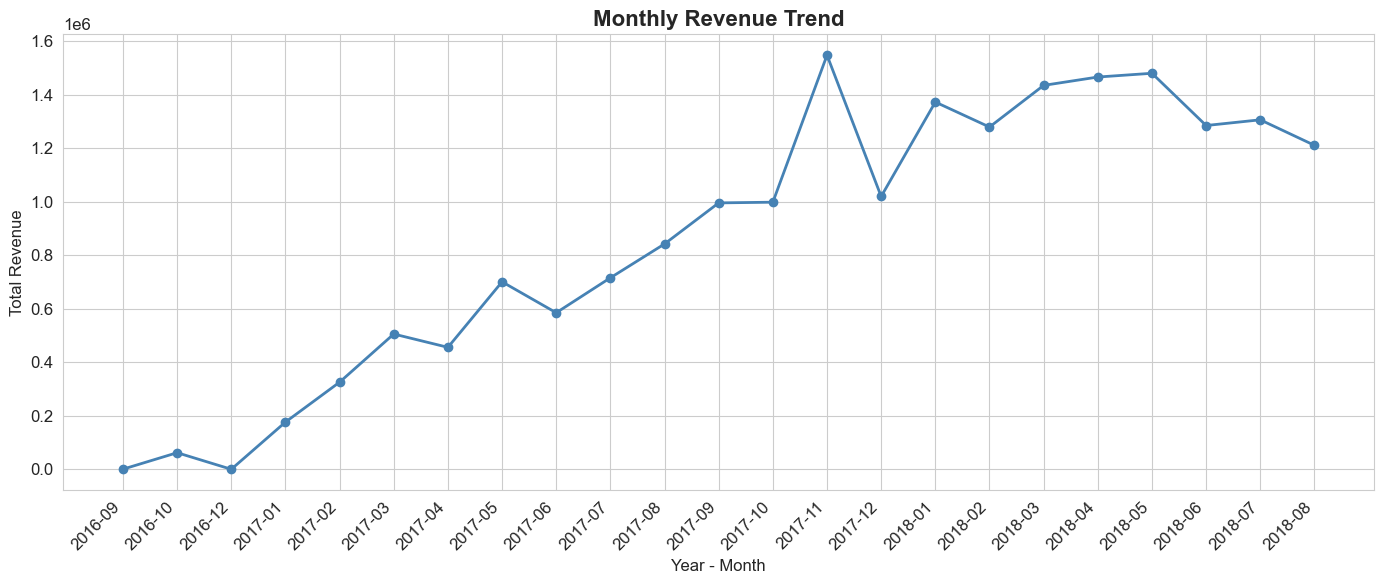

In [144]:
# TIME SERIES 1: MONTHLY REVENUE TREND

monthly_revenue = master.groupby(['order_purchase_year',
                                   'order_purchase_month']).agg(
    total_revenue = ('total_order_value', 'sum')
).reset_index()

monthly_revenue['year_month'] = (
    monthly_revenue['order_purchase_year'].astype(str) + '-' +
    monthly_revenue['order_purchase_month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['year_month'],
         monthly_revenue['total_revenue'],
         marker='o', linewidth=2, color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year - Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

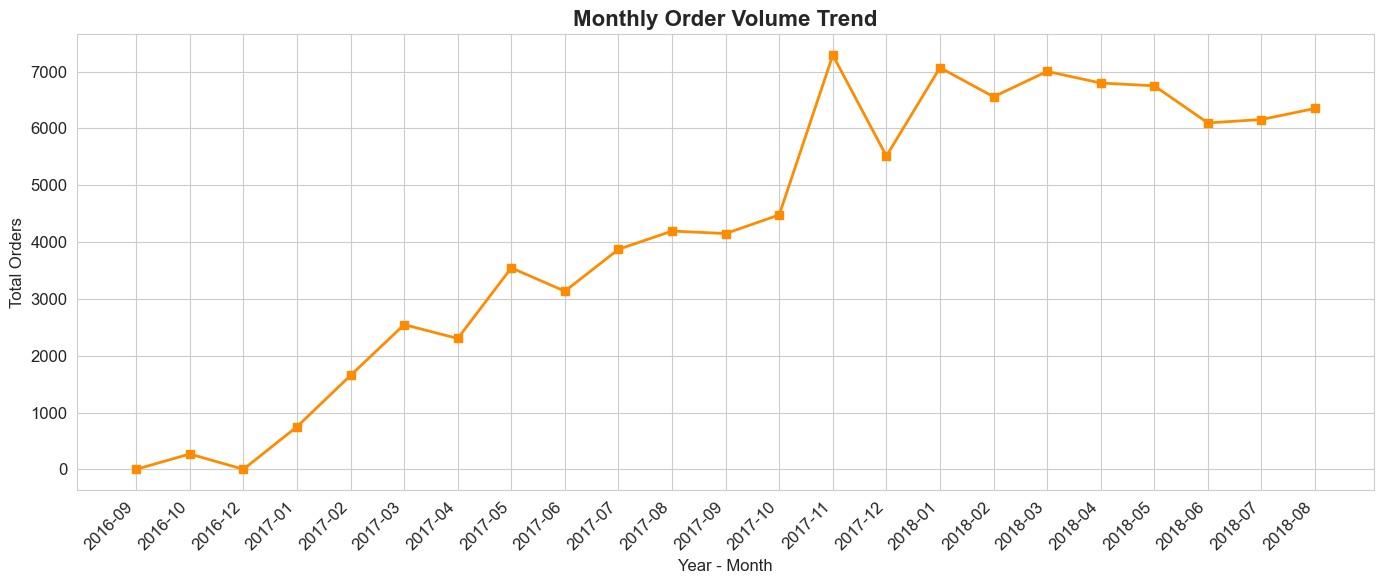

In [145]:
# TIME SERIES 2: MONTHLY ORDER VOLUME TREND

monthly_orders = master.groupby(['order_purchase_year',
                                  'order_purchase_month']).agg(
    total_orders = ('order_id', 'nunique')
).reset_index()

monthly_orders['year_month'] = (
    monthly_orders['order_purchase_year'].astype(str) + '-' +
    monthly_orders['order_purchase_month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_orders['year_month'],
         monthly_orders['total_orders'],
         marker='s', linewidth=2, color='darkorange')
plt.title('Monthly Order Volume Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year - Month', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

BAR CHARTS

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\883818089.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories,


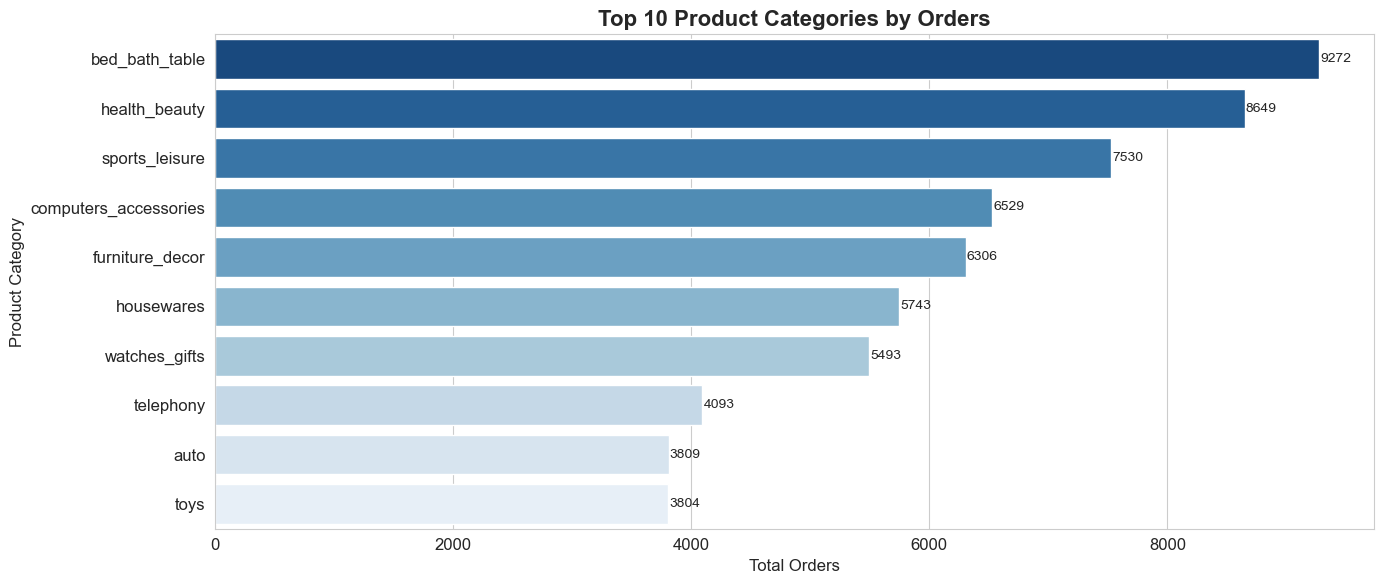

In [146]:
# BAR CHART 1: TOP 10 PRODUCT CATEGORIES BY ORDERS

top_categories = master.groupby('product_category_name_english').agg(
    total_orders = ('order_id', 'nunique')
).reset_index().sort_values('total_orders', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=top_categories,
            x='total_orders',
            y='product_category_name_english',
            palette='Blues_r')
plt.title('Top 10 Product Categories by Orders', fontsize=16, fontweight='bold')
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
for i, v in enumerate(top_categories['total_orders']):
    plt.text(v + 10, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\2546350341.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue_categories,


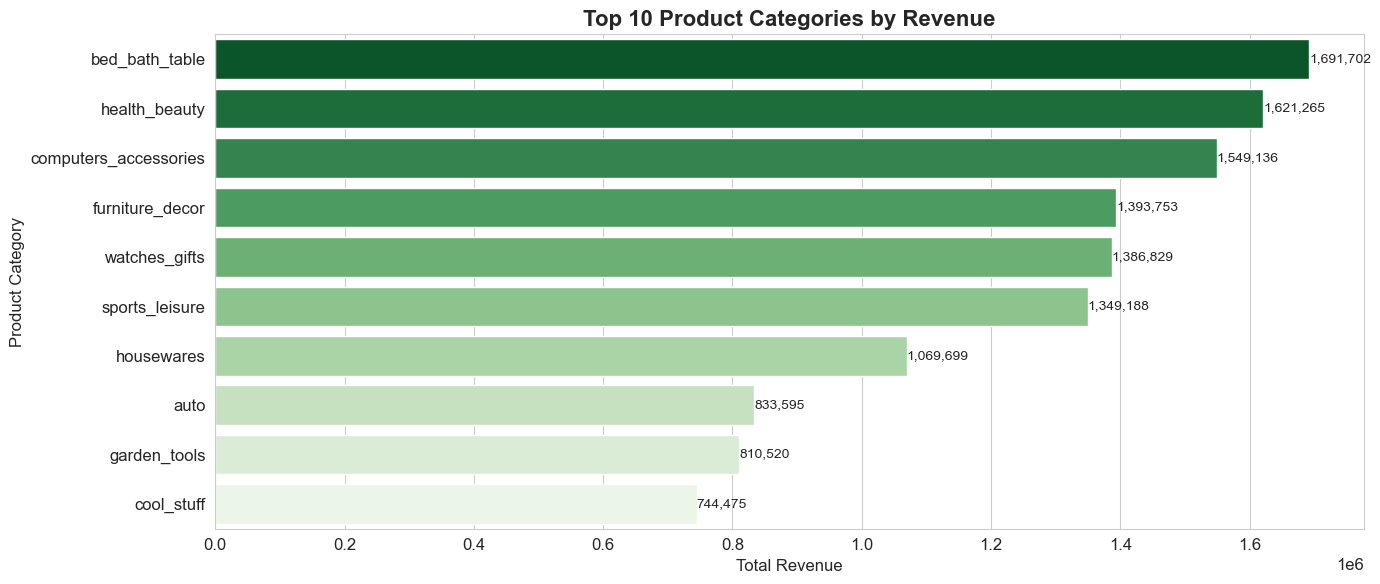

In [147]:
# BAR CHART 2: TOP 10 PRODUCT CATEGORIES BY REVENUE

top_revenue_categories = master.groupby('product_category_name_english').agg(
    total_revenue = ('total_order_value', 'sum')
).reset_index().sort_values('total_revenue', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=top_revenue_categories,
            x='total_revenue',
            y='product_category_name_english',
            palette='Greens_r')
plt.title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
for i, v in enumerate(top_revenue_categories['total_revenue']):
    plt.text(v + 10, i, f'{v:,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\3953494159.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states,


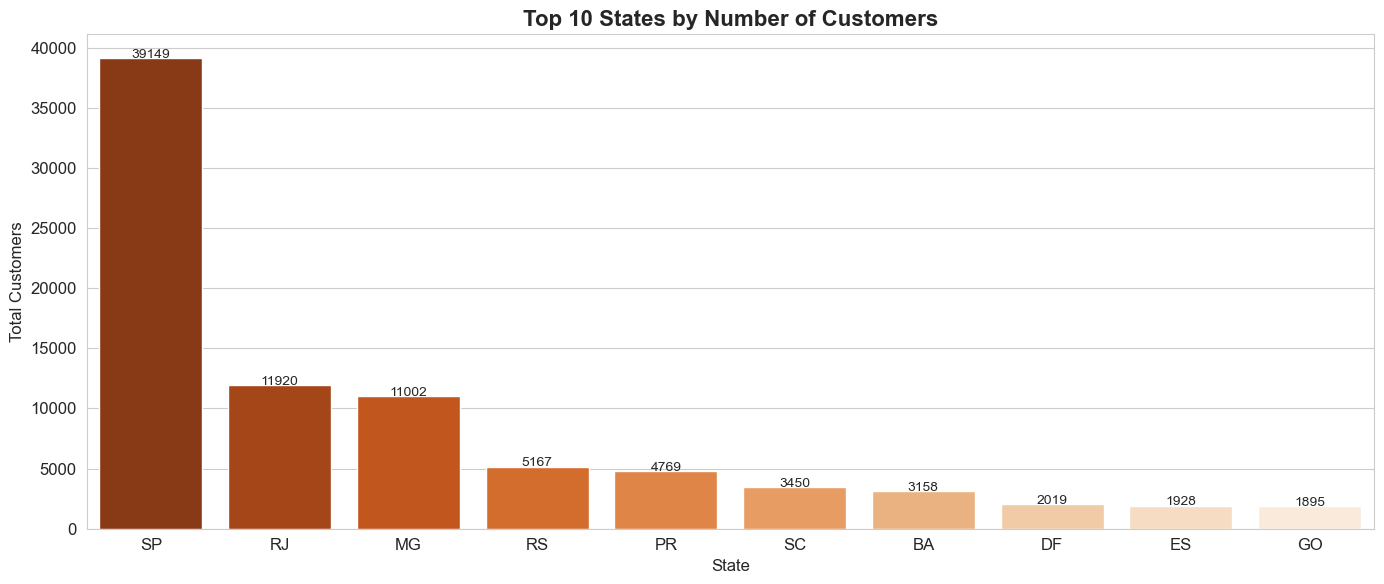

In [148]:
# BAR CHART 3: TOP 10 STATES BY CUSTOMERS

top_states = master.groupby('customer_state').agg(
    total_customers = ('customer_unique_id', 'nunique')
).reset_index().sort_values('total_customers', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=top_states,
            x='customer_state',
            y='total_customers',
            palette='Oranges_r')
plt.title('Top 10 States by Number of Customers', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Customers', fontsize=12)
for i, v in enumerate(top_states['total_customers']):
    plt.text(i, v + 10, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\3508540417.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_counts = master.groupby('customer_segment').agg(
C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\3508540417.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts,
C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\3508540417.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts,


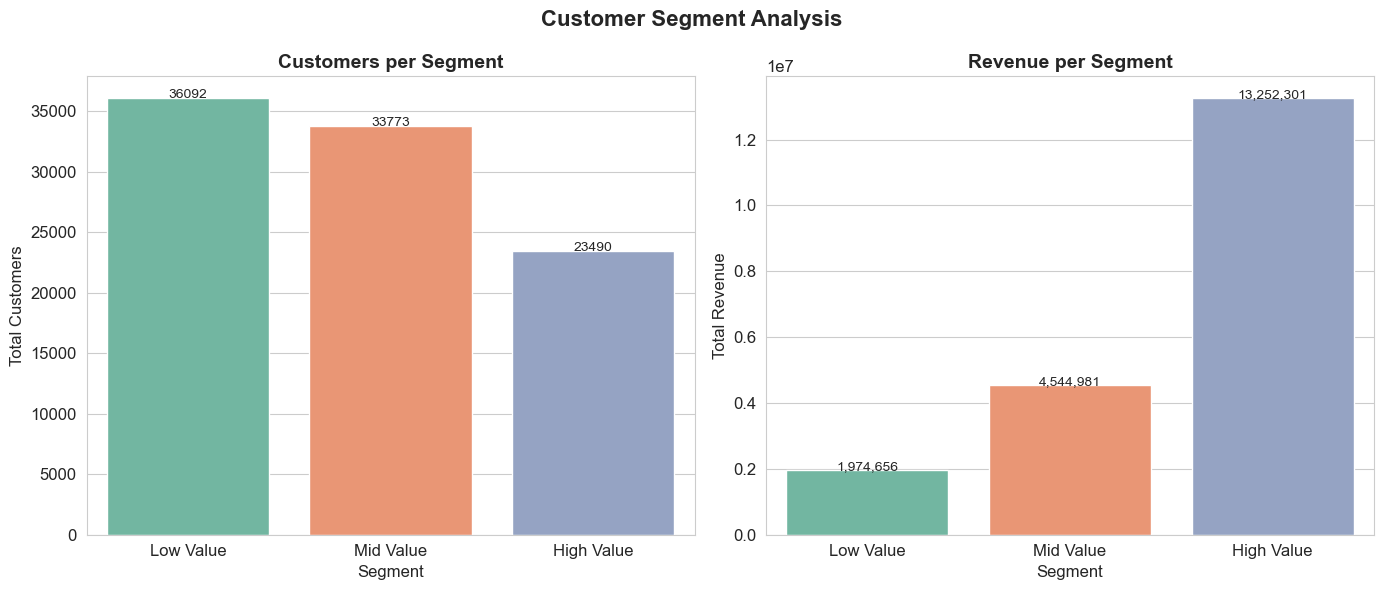

In [149]:
# BAR CHART 4: CUSTOMER SEGMENTS

segment_counts = master.groupby('customer_segment').agg(
    total_customers = ('customer_unique_id', 'nunique'),
    total_revenue   = ('total_order_value',  'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Customers per segment
sns.barplot(data=segment_counts,
            x='customer_segment',
            y='total_customers',
            palette='Set2',
            ax=axes[0])
axes[0].set_title('Customers per Segment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segment', fontsize=12)
axes[0].set_ylabel('Total Customers', fontsize=12)
for i, v in enumerate(segment_counts['total_customers']):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10)

# Revenue per segment
sns.barplot(data=segment_counts,
            x='customer_segment',
            y='total_revenue',
            palette='Set2',
            ax=axes[1])
axes[1].set_title('Revenue per Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segment', fontsize=12)
axes[1].set_ylabel('Total Revenue', fontsize=12)
for i, v in enumerate(segment_counts['total_revenue']):
    axes[1].text(i, v + 10, f'{v:,.0f}', ha='center', fontsize=10)

plt.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\807089427.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_dist,


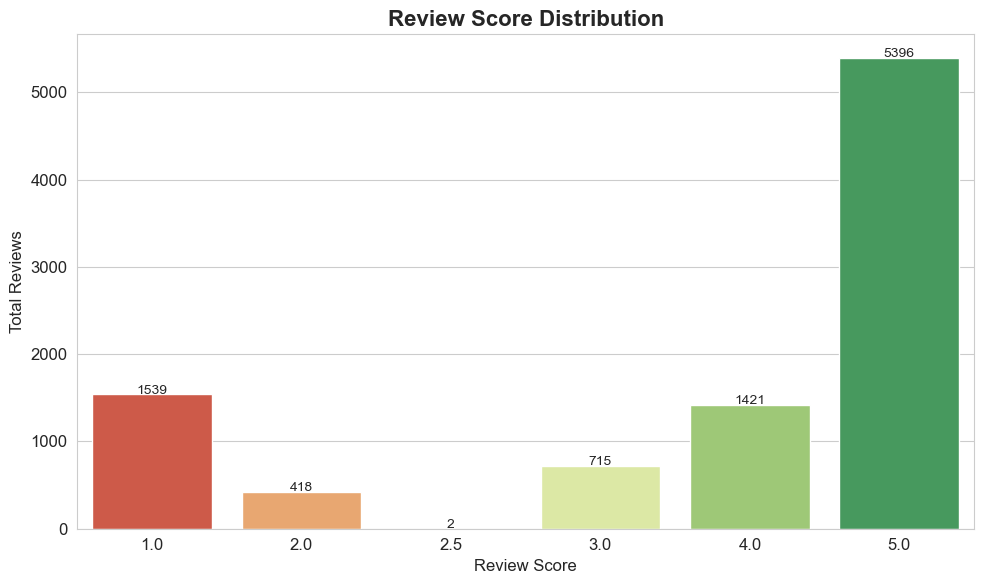

In [150]:
# BAR CHART 5: REVIEW SCORE DISTRIBUTION

review_dist = master.groupby('review_score').agg(
    total_reviews = ('order_id', 'nunique')
).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=review_dist,
            x='review_score',
            y='total_reviews',
            palette='RdYlGn')
plt.title('Review Score Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Total Reviews', fontsize=12)
for i, v in enumerate(review_dist['total_reviews']):
    plt.text(i, v + 10, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

HISTOGRAMs

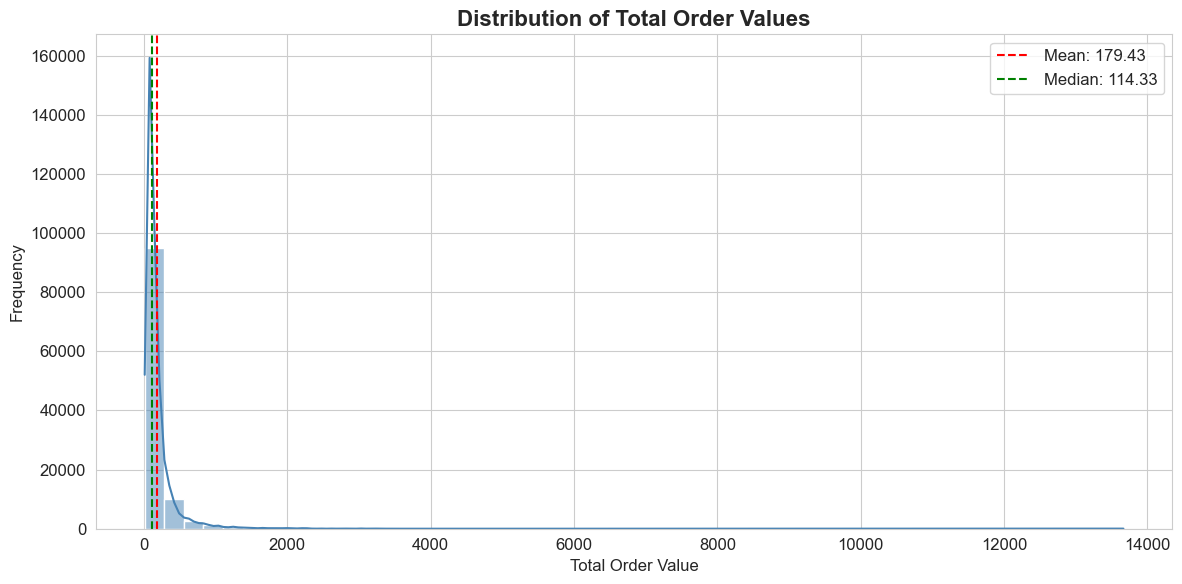

In [151]:
# HISTOGRAM 1: DISTRIBUTION OF ORDER VALUES

plt.figure(figsize=(12, 6))
sns.histplot(master['total_order_value'].dropna(),
             bins=50,
             kde=True,
             color='steelblue')
plt.title('Distribution of Total Order Values', fontsize=16, fontweight='bold')
plt.xlabel('Total Order Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(master['total_order_value'].mean(),
            color='red', linestyle='--', label=f"Mean: {master['total_order_value'].mean():.2f}")
plt.axvline(master['total_order_value'].median(),
            color='green', linestyle='--', label=f"Median: {master['total_order_value'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

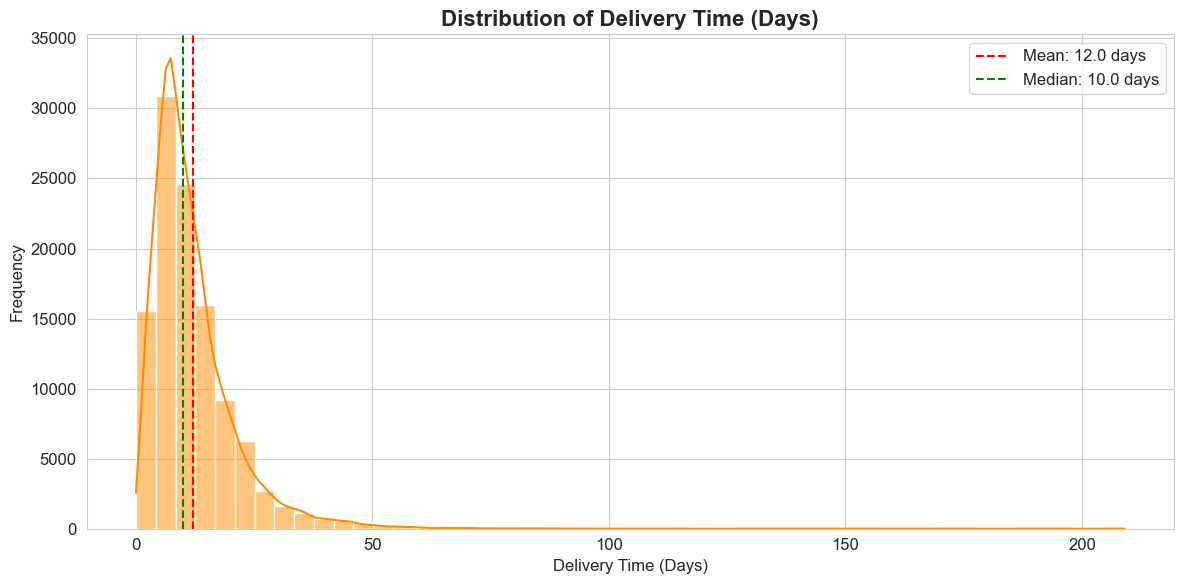

In [152]:
# HISTOGRAM 2: DISTRIBUTION OF DELIVERY TIME

plt.figure(figsize=(12, 6))
sns.histplot(master['delivery_time_days'].dropna(),
             bins=50,
             kde=True,
             color='darkorange')
plt.title('Distribution of Delivery Time (Days)', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Time (Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(master['delivery_time_days'].mean(),
            color='red', linestyle='--', label=f"Mean: {master['delivery_time_days'].mean():.1f} days")
plt.axvline(master['delivery_time_days'].median(),
            color='green', linestyle='--', label=f"Median: {master['delivery_time_days'].median():.1f} days")
plt.legend()
plt.tight_layout()
plt.show()

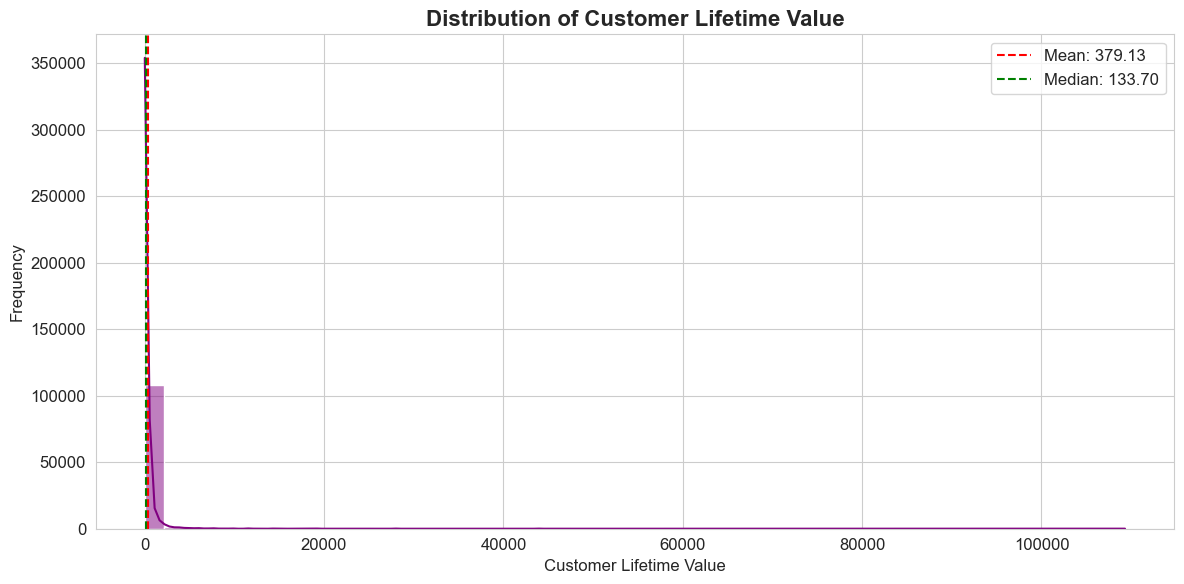

In [153]:
# HISTOGRAM 3: DISTRIBUTION OF CUSTOMER LIFETIME VALUE

plt.figure(figsize=(12, 6))
sns.histplot(master['customer_lifetime_value'].dropna(),
             bins=50,
             kde=True,
             color='purple')
plt.title('Distribution of Customer Lifetime Value', fontsize=16, fontweight='bold')
plt.xlabel('Customer Lifetime Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(master['customer_lifetime_value'].mean(),
            color='red', linestyle='--', label=f"Mean: {master['customer_lifetime_value'].mean():.2f}")
plt.axvline(master['customer_lifetime_value'].median(),
            color='green', linestyle='--', label=f"Median: {master['customer_lifetime_value'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

BOX PLOTS

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\2128086609.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master,


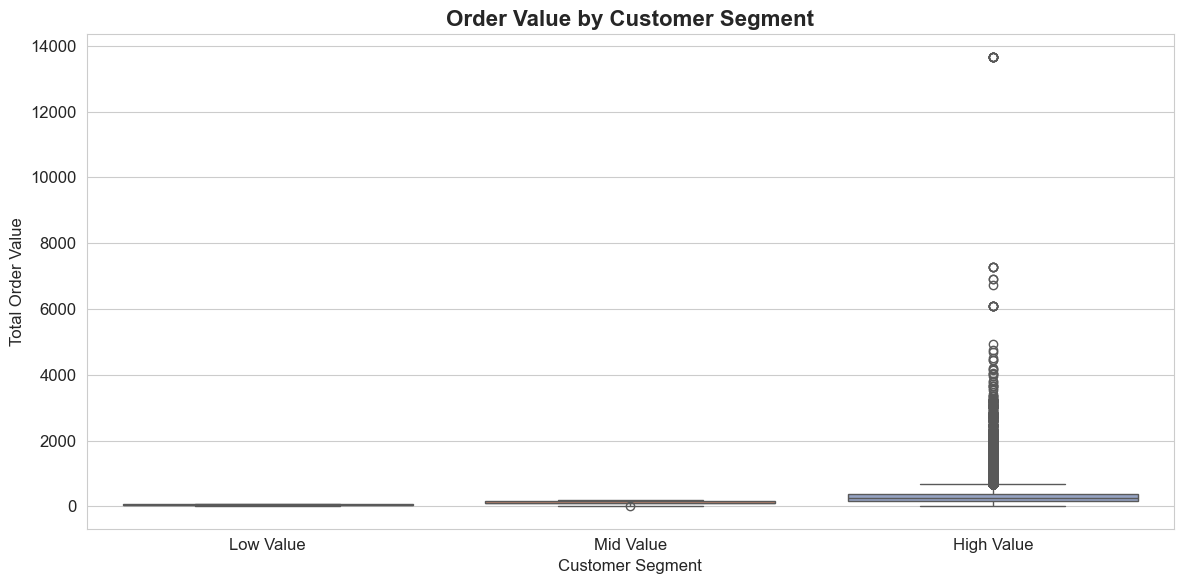

In [154]:
# BOX PLOT 1: ORDER VALUE BY CUSTOMER SEGMENT

plt.figure(figsize=(12, 6))
sns.boxplot(data=master,
            x='customer_segment',
            y='total_order_value',
            palette='Set2')
plt.title('Order Value by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Order Value', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\1714627882.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master,


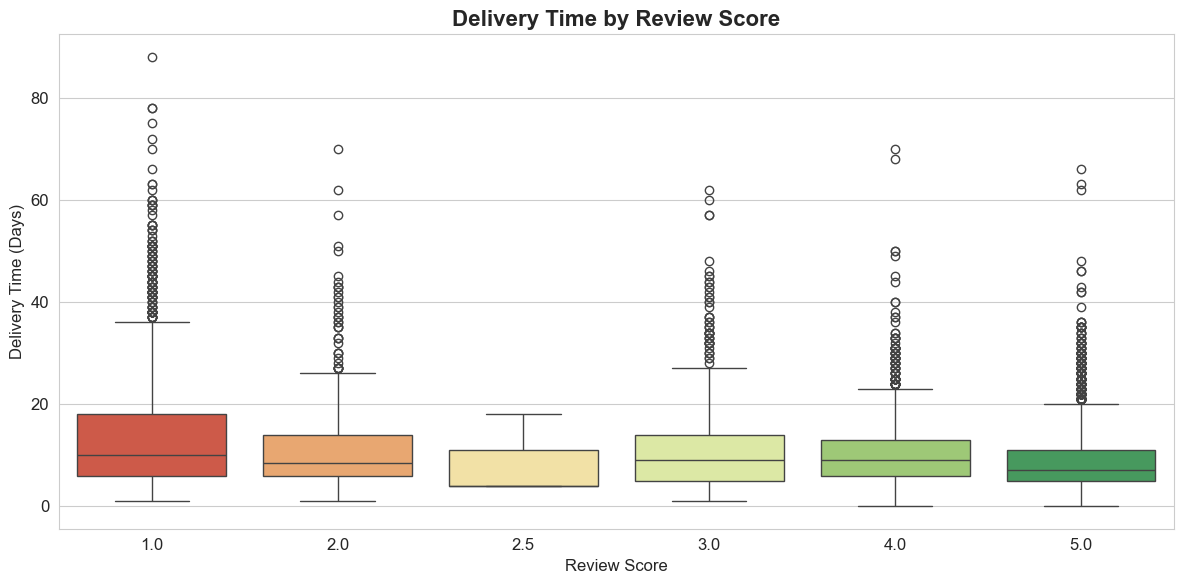

In [155]:
# BOX PLOT 2: DELIVERY TIME BY REVIEW SCORE

plt.figure(figsize=(12, 6))
sns.boxplot(data=master,
            x='review_score',
            y='delivery_time_days',
            palette='RdYlGn')
plt.title('Delivery Time by Review Score', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Delivery Time (Days)', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\4088327489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master,


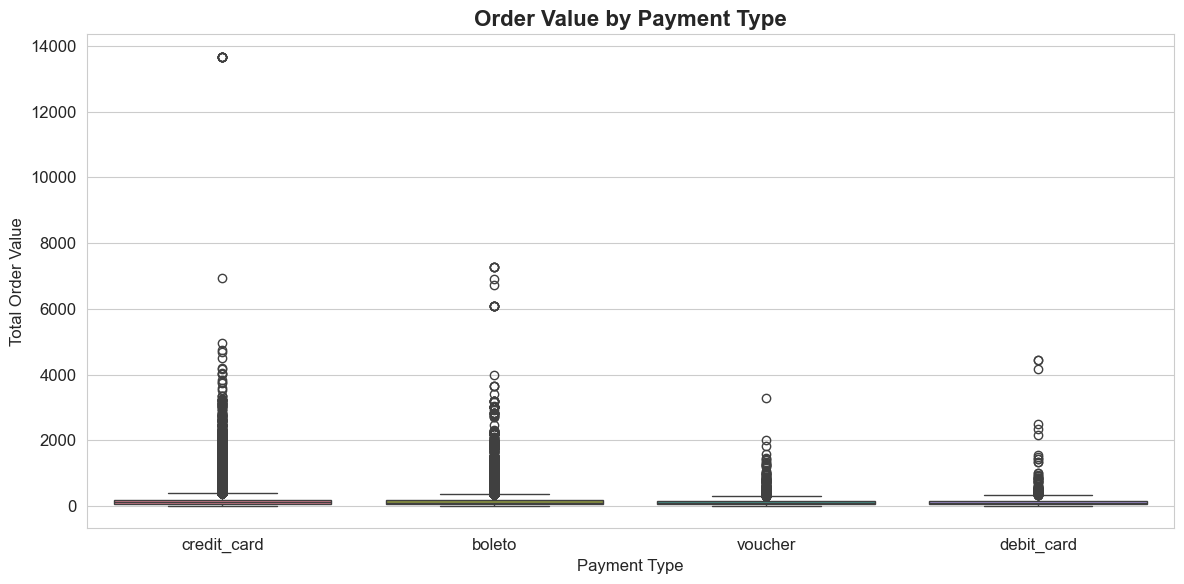

In [156]:
# BOX PLOT 3: ORDER VALUE BY PAYMENT TYPE

plt.figure(figsize=(12, 6))
sns.boxplot(data=master,
            x='payment_type',
            y='total_order_value',
            palette='husl')
plt.title('Order Value by Payment Type', fontsize=16, fontweight='bold')
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Total Order Value', fontsize=12)
plt.tight_layout()
plt.show()

HEATMAPS

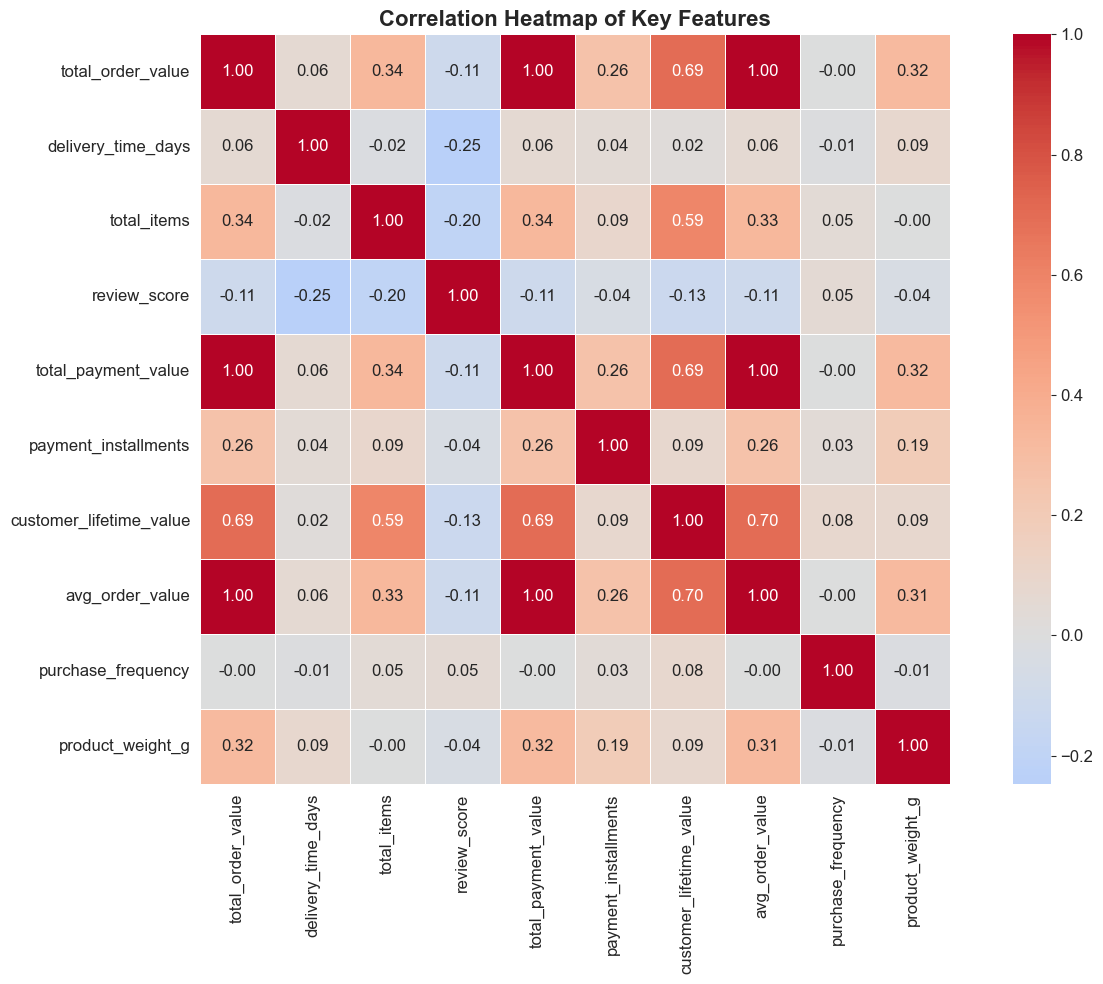

In [157]:
# HEATMAP 1: CORRELATION ANALYSIS

corr_cols = [
    'total_order_value',
    'delivery_time_days',
    'total_items',
    'review_score',
    'total_payment_value',
    'payment_installments',
    'customer_lifetime_value',
    'avg_order_value',
    'purchase_frequency',
    'product_weight_g'
]

correlation_matrix = master[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            square=True)
plt.title('Correlation Heatmap of Key Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

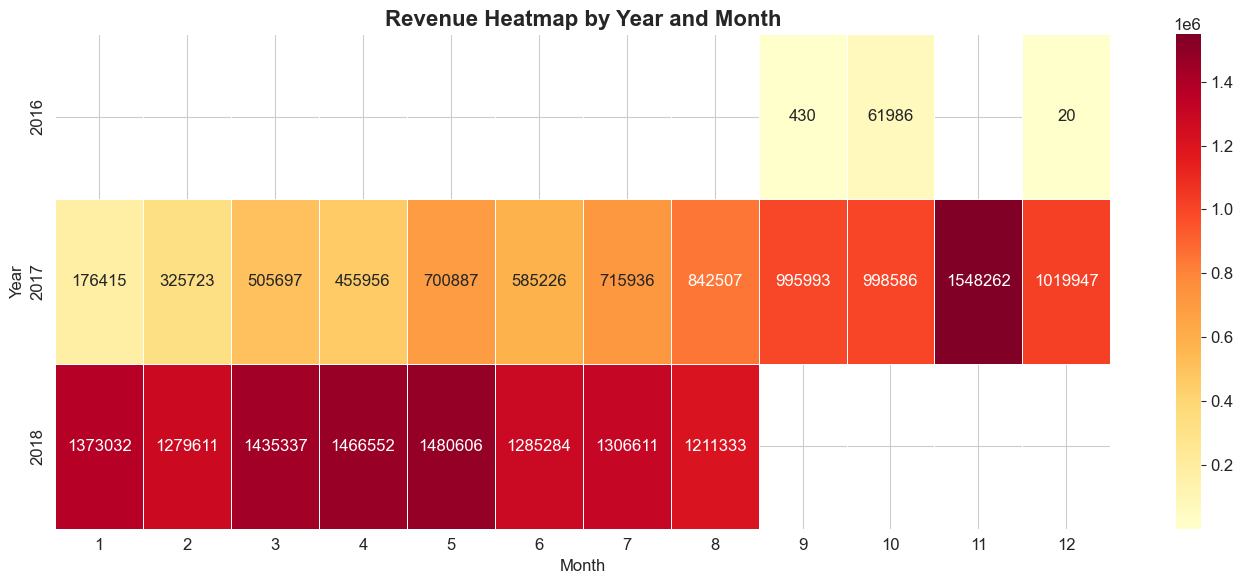

In [158]:
# HEATMAP 2: REVENUE BY YEAR AND MONTH

revenue_pivot = master.groupby(['order_purchase_year',
                                 'order_purchase_month'])['total_order_value'].sum().reset_index()

revenue_pivot = revenue_pivot.pivot(index='order_purchase_year',
                                     columns='order_purchase_month',
                                     values='total_order_value')

plt.figure(figsize=(14, 6))
sns.heatmap(revenue_pivot,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('Revenue Heatmap by Year and Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

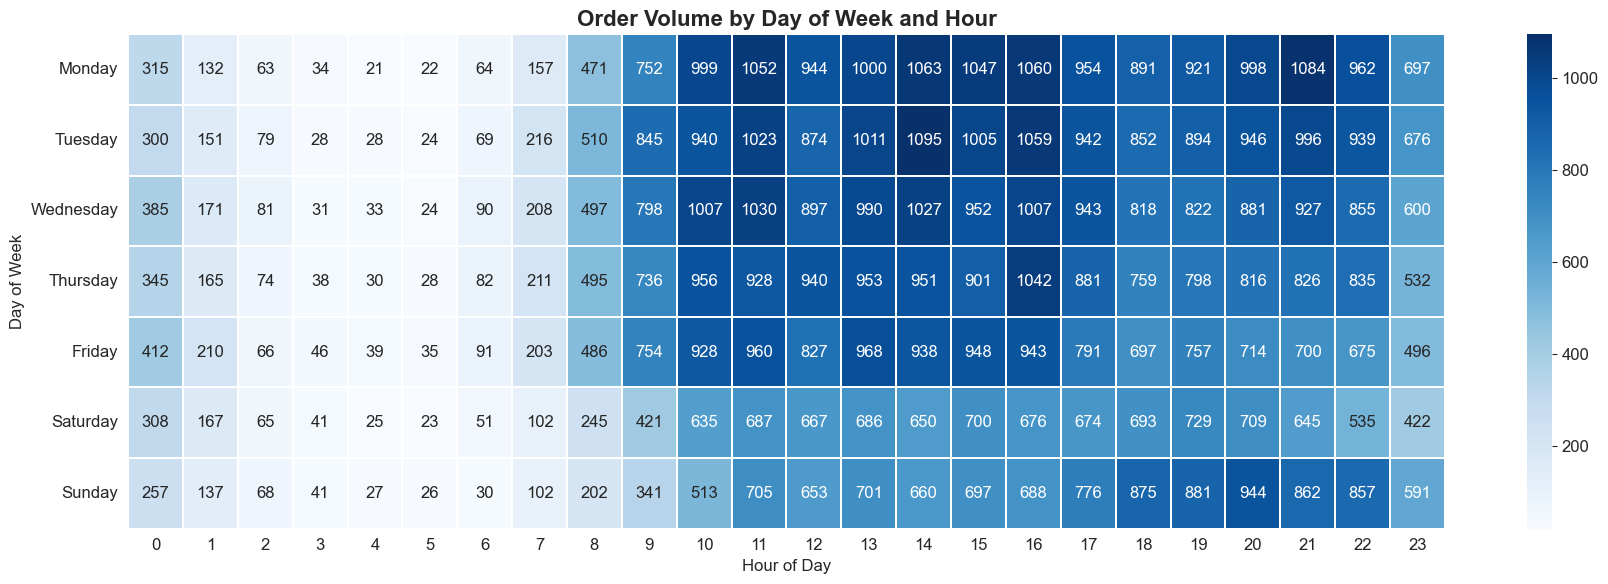

In [159]:
# HEATMAP 3: ORDERS BY DAY OF WEEK AND HOUR

orders_pivot = master.groupby(['order_purchase_dayofweek',
                                'order_purchase_hour'])['order_id'].nunique().reset_index()

orders_pivot = orders_pivot.pivot(index='order_purchase_dayofweek',
                                   columns='order_purchase_hour',
                                   values='order_id')

# Sort days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_pivot = orders_pivot.reindex(day_order)

plt.figure(figsize=(18, 6))
sns.heatmap(orders_pivot,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            linewidths=0.3)
plt.title('Order Volume by Day of Week and Hour', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

Business Insights and Recommendations
You must derive clear and actionable insights:
•	Identify top revenue-driving factors 
•	Highlight customer behavior patterns 
•	Evaluate operational inefficiencies 
•	Provide strategic recommendations 
Insights must be supported by data and visual evidence.

In [175]:
# INSIGHT 1: TOP REVENUE DRIVING FACTORS

print("=" * 60)
print("1. TOP REVENUE DRIVING FACTORS")
print("=" * 60)

# Total Revenue
total_revenue = master['total_order_value'].sum()
print(f"\nTotal Revenue Generated : Rs {total_revenue:,.2f}")

# Top 5 Revenue Categories
top_rev_categories = master.groupby('product_category_name_english').agg(
    total_revenue = ('total_order_value', 'sum')
).reset_index().sort_values('total_revenue', ascending=False).head(5)

top_rev_categories['revenue_pct'] = (
    top_rev_categories['total_revenue'] / total_revenue * 100
).round(2)

print("\nTop 5 Revenue Driving Categories:")
display(top_rev_categories)

# Top Payment Type by Revenue
top_payment = master.groupby('payment_type').agg(
    total_revenue = ('total_order_value', 'sum'),
    total_orders  = ('order_id',          'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

print("\nRevenue by Payment Type:")
display(top_payment)

# Top States by Revenue
top_states_rev = master.groupby('customer_state').agg(
    total_revenue = ('total_order_value', 'sum')
).reset_index().sort_values('total_revenue', ascending=False).head(5)

top_states_rev['revenue_pct'] = (
    top_states_rev['total_revenue'] / total_revenue * 100
).round(2)

print("\nTop 5 States by Revenue:")
display(top_states_rev)

print("\n KEY INSIGHT:")
print(f"  - Top category '{top_rev_categories.iloc[0]['product_category_name_english']}' contributes {top_rev_categories.iloc[0]['revenue_pct']}% of total revenue")
print(f"  - Top state '{top_states_rev.iloc[0]['customer_state']}' contributes {top_states_rev.iloc[0]['revenue_pct']}% of total revenue")
print(f"  - '{top_payment.iloc[0]['payment_type']}' is the most preferred payment method")

1. TOP REVENUE DRIVING FACTORS

Total Revenue Generated : Rs 19,771,937.90

Top 5 Revenue Driving Categories:


,product_category_name_english,total_revenue,revenue_pct
7,bed_bath_table,1691702.33,8.56
43,health_beauty,1621265.32,8.20
15,computers_accessories,1549136.18,7.84
39,furniture_decor,1393752.56,7.05
70,watches_gifts,1386828.73,7.01



Revenue by Payment Type:


,payment_type,total_revenue,total_orders
1,credit_card,15207234.65,73218
0,boleto,3943080.91,19191
3,voucher,374806.74,2582
2,debit_card,246385.22,1483



Top 5 States by Revenue:


,customer_state,total_revenue,revenue_pct
25,SP,7402533.97,37.44
18,RJ,2689035.64,13.60
10,MG,2280614.53,11.53
22,RS,1110441.11,5.62
17,PR,1030030.40,5.21



 KEY INSIGHT:
  - Top category 'bed_bath_table' contributes 8.56% of total revenue
  - Top state 'SP' contributes 37.44% of total revenue
  - 'credit_card' is the most preferred payment method


In [163]:
# INSIGHT 2: CUSTOMER BEHAVIOR PATTERNS

print("=" * 60)
print("2. CUSTOMER BEHAVIOR PATTERNS")
print("=" * 60)

# New vs Repeat
total_customers  = master['customer_unique_id'].nunique()
repeat_customers = (master.groupby('customer_unique_id')['order_id'].nunique() > 1).sum()
new_customers    = total_customers - repeat_customers

print(f"\nTotal Unique Customers  : {total_customers:,}")
print(f"New Customers           : {new_customers:,}  ({new_customers/total_customers*100:.1f}%)")
print(f"Repeat Customers        : {repeat_customers:,}  ({repeat_customers/total_customers*100:.1f}%)")

# Customer Segments
segment_summary = master.groupby('customer_segment').agg(
    total_customers = ('customer_unique_id', 'nunique'),
    total_revenue   = ('total_order_value',  'sum'),
    avg_clv         = ('customer_lifetime_value', 'mean'),
    avg_order_value = ('avg_order_value',    'mean')
).reset_index()

segment_summary['revenue_pct'] = (
    segment_summary['total_revenue'] / total_revenue * 100
).round(2)

print("\nCustomer Segment Summary:")
display(segment_summary)

# Purchase Frequency
avg_frequency = master['purchase_frequency'].mean()
max_frequency = master['purchase_frequency'].max()

print(f"\nAverage Purchase Frequency : {avg_frequency:.2f} orders per customer")
print(f"Maximum Purchase Frequency : {max_frequency:.0f} orders by one customer")

# Peak shopping hours
peak_hour = master.groupby('order_purchase_hour')['order_id'].nunique()
peak_hour = peak_hour.idxmax()

peak_day  = master.groupby('order_purchase_dayofweek')['order_id'].nunique()
peak_day  = peak_day.idxmax()

print(f"\nPeak Shopping Hour : {peak_hour}:00")
print(f"Peak Shopping Day  : {peak_day}")

print("\n KEY INSIGHT:")
print(f"  - {new_customers/total_customers*100:.1f}% customers are one-time buyers — retention strategy needed")
print(f"  - High Value customers drive the most revenue despite being fewer in number")
print(f"  - Most orders placed at {peak_hour}:00 on {peak_day}s")

2. CUSTOMER BEHAVIOR PATTERNS

Total Unique Customers  : 93,355
New Customers           : 90,554  (97.0%)
Repeat Customers        : 2,801  (3.0%)

Customer Segment Summary:


C:\Users\tarak\AppData\Local\Temp\ipykernel_25120\38808212.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = master.groupby('customer_segment').agg(


,customer_segment,total_customers,total_revenue,avg_clv,avg_order_value,revenue_pct
0,Low Value,36092,1974656.13,54.839502,54.301007,9.99
1,Mid Value,33773,4544981.00,135.620578,124.985728,22.99
2,High Value,23490,13252300.77,930.248053,353.715389,67.03



Average Purchase Frequency : 1.08 orders per customer
Maximum Purchase Frequency : 15 orders by one customer

Peak Shopping Hour : 16:00
Peak Shopping Day  : Monday

 KEY INSIGHT:
  - 97.0% customers are one-time buyers — retention strategy needed
  - High Value customers drive the most revenue despite being fewer in number
  - Most orders placed at 16:00 on Mondays


In [165]:
# INSIGHT 3: OPERATIONAL INEFFICIENCIES

print("=" * 60)
print("3. OPERATIONAL INEFFICIENCIES")
print("=" * 60)

# Average Delivery Time
avg_delivery = master['delivery_time_days'].mean()
max_delivery = master['delivery_time_days'].max()
min_delivery = master['delivery_time_days'].min()

print(f"\nDelivery Time Stats:")
print(f"  Average Delivery Time : {avg_delivery:.1f} days")
print(f"  Minimum Delivery Time : {min_delivery:.0f} days")
print(f"  Maximum Delivery Time : {max_delivery:.0f} days")

# Delayed Orders
master['is_delayed'] = master['delivery_time_days'] > master['delivery_time_days'].mean()
delayed_orders   = master[master['is_delayed'] == True]['order_id'].nunique()
total_orders     = master['order_id'].nunique()
delay_rate       = delayed_orders / total_orders * 100

print(f"\nTotal Orders      : {total_orders:,}")
print(f"Delayed Orders    : {delayed_orders:,}  ({delay_rate:.1f}%)")
print(f"On Time Orders    : {total_orders - delayed_orders:,}  ({100-delay_rate:.1f}%)")

# Delivery time vs Review Score
delivery_by_score = master.groupby('review_score').agg(
    avg_delivery_days = ('delivery_time_days', 'mean')
).reset_index()

print("\nAverage Delivery Time by Review Score:")
display(delivery_by_score)

# Low rated categories
low_rated = master[master['review_score'] <= 2].groupby(
    'product_category_name_english').agg(
    total_low_ratings = ('order_id', 'nunique')
).reset_index().sort_values('total_low_ratings', ascending=False).head(5)

print("\nTop 5 Categories with Low Ratings (score ≤ 2):")
display(low_rated)

# Orders with missing delivery info
missing_delivery = master['order_delivered_customer_date'].isnull().sum()
print(f"\nOrders with Missing Delivery Date : {missing_delivery:,}")

print("\n KEY INSIGHT:")
print(f"  - Average delivery time is {avg_delivery:.1f} days — room for improvement")
print(f"  - {delay_rate:.1f}% of orders are delayed — impacts customer satisfaction")
print(f"  - Low review scores strongly correlate with longer delivery times")
print(f"  - Top dissatisfied category: '{low_rated.iloc[0]['product_category_name_english']}'")

3. OPERATIONAL INEFFICIENCIES

Delivery Time Stats:
  Average Delivery Time : 12.0 days
  Minimum Delivery Time : 0 days
  Maximum Delivery Time : 209 days

Total Orders      : 96,475
Delayed Orders    : 34,590  (35.9%)
On Time Orders    : 61,885  (64.1%)

Average Delivery Time by Review Score:


,review_score,avg_delivery_days
0,1.0,13.892315
1,2.0,11.421429
2,2.5,8.666667
3,3.0,10.901895
4,4.0,10.320218
5,5.0,8.534342



Top 5 Categories with Low Ratings (score ≤ 2):


,product_category_name_english,total_low_ratings
7,bed_bath_table,221
58,watches_gifts,201
34,health_beauty,179
14,computers_accessories,144
40,housewares,138



Orders with Missing Delivery Date : 0

 KEY INSIGHT:
  - Average delivery time is 12.0 days — room for improvement
  - 35.9% of orders are delayed — impacts customer satisfaction
  - Low review scores strongly correlate with longer delivery times
  - Top dissatisfied category: 'bed_bath_table'


In [184]:
print("STRATEGIC RECOMMENDATIONS")
print("BASED ON: TOP REVENUE DRIVING FACTORS")

print("""
------------------------------------------------------------
RECOMMENDATION 1: FOCUS ON TOP 5 REVENUE CATEGORIES
------------------------------------------------------------
Data:
  bed_bath_table        : Rs 1,691,702  (8.56%)
  health_beauty         : Rs 1,621,265  (8.20%)
  computers_accessories : Rs 1,549,136  (7.84%)
  furniture_decor       : Rs 1,393,752  (7.05%)
  watches_gifts         : Rs 1,386,828  (7.01%)
  Combined contribution : 38.66% of total revenue

Problem:
  Only 5 categories out of many are driving nearly 40% of total revenue. Other categories
  are significantly underperforming.

Action:
  Increase product variety in these 5 categories by recruiting more sellers.
  Run targeted promotions like bundle offers specifically for these categories.
  Feature these categories on the homepage.

Expected Result:
  10 to 15 percent increase in revenue
  from top 5 categories.

------------------------------------------------------------
RECOMMENDATION 2: GROW CREDIT CARD PAYMENT CHANNEL
------------------------------------------------------------
Data:
  Credit Card : Rs 15,207,234  (76.9% of revenue, 73,218 orders)
  Boleto      : Rs 3,943,080   (19.9% of revenue, 19,191 orders)
  Voucher     : Rs 374,806     (1.9% of revenue)
  Debit Card  : Rs 246,385     (1.2% of revenue)

Problem:
  Debit card and voucher together contribute only 3.1% of revenue. There is a large
  opportunity to grow these payment channels. 
  
  Action:
  Partner with top banks to offer installment plans on credit card orders above Rs 300.
  Offer a small discount on boleto payments to retain and grow that customer segment.
  Increase voucher distribution through
  referral programs.

Expected Result:
  8 to 10 percent increase in payment conversion rate.

------------------------------------------------------------
RECOMMENDATION 3: REDUCE GEOGRAPHIC DEPENDENCY ON SP
------------------------------------------------------------
Data:
  SP : Rs 7,402,533  (37.44% of total revenue)
  RJ : Rs 2,689,035  (13.60%)
  MG : Rs 2,280,614  (11.53%)
  RS : Rs 1,110,441  (5.62%)
  PR : Rs 1,030,030  (5.21%)
  Top 3 states alone contribute 62.57% of revenue.

Problem:
  The business is too dependent on SP for revenue.
  If the SP market slows down it will heavily impact total revenue.

Action:
  Set up warehouses in SP, RJ and MG to protect and serve these key markets better.
  Launch targeted marketing campaigns in RS and PR to grow their contribution.
  Run state specific discount campaigns in the bottom 10 revenue states for 3 months.
  Recruit local sellers in low revenue states to improve product availability.

Expected Result:
  Reduce SP dependency from 37 percent to 30 percent. Grow bottom states revenue by 20 percent.
""")

STRATEGIC RECOMMENDATIONS
BASED ON: TOP REVENUE DRIVING FACTORS

------------------------------------------------------------
RECOMMENDATION 1: FOCUS ON TOP 5 REVENUE CATEGORIES
------------------------------------------------------------
Data:
  bed_bath_table        : Rs 1,691,702  (8.56%)
  health_beauty         : Rs 1,621,265  (8.20%)
  computers_accessories : Rs 1,549,136  (7.84%)
  furniture_decor       : Rs 1,393,752  (7.05%)
  watches_gifts         : Rs 1,386,828  (7.01%)
  Combined contribution : 38.66% of total revenue

Problem:
  Only 5 categories out of many are driving nearly 40% of total revenue. Other categories
  are significantly underperforming.

Action:
  Increase product variety in these 5 categories by recruiting more sellers.
  Run targeted promotions like bundle offers specifically for these categories.
  Feature these categories on the homepage.

Expected Result:
  10 to 15 percent increase in revenue
  from top 5 categories.

-----------------------------------

In [185]:
print("STRATEGIC RECOMMENDATIONS")
print("BASED ON: CUSTOMER BEHAVIOR PATTERNS")

print("""
------------------------------------------------------------
RECOMMENDATION 4: SOLVE THE 97 PERCENT ONE-TIME BUYER PROBLEM
------------------------------------------------------------
Data:
  Total Customers   : 93,355
  New Customers     : 90,554  (97.0%)
  Repeat Customers  : 2,801   (3.0%)
  Avg Frequency     : 1.08 orders per customer
  Max Frequency     : 15 orders by one customer

Problem:
  97 out of every 100 customers never come back. The business is spending money on acquiring customers but failing to retain them. 
  Industry average repeat rate is 20 to 30 percent. This business is at just 3 percent which is a critical problem.

Action:
  Send an automated follow-up email 7 days after delivery with a 10 percent discount for the next purchase. Launch a loyalty points program 
  where every Rs 10 spent earns 1 point redeemable on future orders. Create a referral program where an existing customer gets Rs 20 voucher 
  for every new customer they refer. Send personalized product recommendations based on past purchase category.
  For customers inactive for 60 or more days send a win-back campaign with 15 percent discount.

Expected Result:
  Increase repeat purchase rate from 3 percent to 10 to 15 percent.
  Revenue increase of Rs 2 to 3 million from retained customers.

------------------------------------------------------------
RECOMMENDATION 5: LAUNCH VIP PROGRAM FOR HIGH VALUE CUSTOMERS
------------------------------------------------------------
Data:
  High Value : 23,490 customers, Rs 13,252,300 (67.03% revenue)
               Avg order value = Rs 353.71
  Mid Value  : 33,773 customers, Rs 4,544,981  (22.99% revenue)
               Avg order value = Rs 124.99
  Low Value  : 36,092 customers, Rs 1,974,656  (9.99% revenue)
               Avg order value = Rs 54.30

Problem:
  High Value customers are only 25 percent of the customer base but generate 67 percent of revenue. They need special treatment to retain them.
  Low Value customers are 39 percent of the base but generate only 10 percent of revenue.

Action:
  For High Value customers:
  Launch a VIP membership with benefits like free express delivery and priority support.
  Give early access to new products and sales.
  Send personalized birthday and anniversary offers.

  For Mid Value customers:
  Target with upgrade campaigns to move them to the High Value segment.
  Offer bundle deals and loyalty bonus points.

  For Low Value customers:
  Run low price promotions to gradually increase their order value.
  Cross-sell higher value products from their preferred categories.

Expected Result:
  Increase High Value segment revenue by 20 to 25 percent. Move 20 percent of Mid Value customers
  to High Value segment.

------------------------------------------------------------
RECOMMENDATION 6: USE PEAK SHOPPING TIME FOR CAMPAIGNS
------------------------------------------------------------
Data:
  Peak Shopping Hour : 16:00 (4 PM)
  Peak Shopping Day  : Monday

Problem:
  The peak shopping pattern is not being used for targeted campaigns and promotions.
  This is a missed opportunity to maximize sales during high engagement windows.

Action:
  Schedule all promotional emails and push notifications to go out at 3:30 PM on Monday.
  Run Monday-only flash sales from 4 PM to 7 PM. Ensure maximum inventory availability on
  Monday afternoons. Schedule social media ads to run between 3 PM and 6 PM on Mondays.

Expected Result:
  10 to 15 percent increase in Monday afternoon sales. 5 to 8 percent overall weekly revenue increase.
""")

STRATEGIC RECOMMENDATIONS
BASED ON: CUSTOMER BEHAVIOR PATTERNS

------------------------------------------------------------
RECOMMENDATION 4: SOLVE THE 97 PERCENT ONE-TIME BUYER PROBLEM
------------------------------------------------------------
Data:
  Total Customers   : 93,355
  New Customers     : 90,554  (97.0%)
  Repeat Customers  : 2,801   (3.0%)
  Avg Frequency     : 1.08 orders per customer
  Max Frequency     : 15 orders by one customer

Problem:
  97 out of every 100 customers never come back. The business is spending money on acquiring customers but failing to retain them. 
  Industry average repeat rate is 20 to 30 percent. This business is at just 3 percent which is a critical problem.

Action:
  Send an automated follow-up email 7 days after delivery with a 10 percent discount for the next purchase. Launch a loyalty points program 
  where every Rs 10 spent earns 1 point redeemable on future orders. Create a referral program where an existing customer gets Rs 20 vouche

In [183]:
print("STRATEGIC RECOMMENDATIONS")
print("BASED ON: OPERATIONAL INEFFICIENCIES")

print("""
------------------------------------------------------------
RECOMMENDATION 7: REDUCE AVERAGE DELIVERY FROM 12 TO 8 DAYS
------------------------------------------------------------
Data:
  Average Delivery Time : 12.0 days
  Maximum Delivery Time : 209 days
  Minimum Delivery Time : 0 days

  Delivery Time by Review Score:
  Score 1 (Worst) : 13.89 days average
  Score 2         : 11.42 days average
  Score 3         : 10.90 days average
  Score 4         : 10.32 days average
  Score 5 (Best)  : 8.53 days average

  Difference between score 1 and score 5 is 5.36 days. Customers who receive in 8.5 days
  give 5 stars. Customers who receive in 13.9 days give 1 star.

Problem:
  Every extra day of delivery leads to a lower review score. Simply reducing delivery time
  will directly improve customer satisfaction.

Action:
  Set a mandatory delivery target of 8 days for all orders.
  Build regional warehouses in SP, RJ and MG to reduce last mile delivery by 3 to 4 days.
  Partner with express logistics providers for orders above Rs 200.
  Add real-time delivery tracking so customers can monitor their orders.
  Investigate the 209 day delivery case immediately and fix the root cause.

Expected Result:
  Reduce average delivery from 12 to 8 days.
  Improve average review score to 4.5 or above.

------------------------------------------------------------
RECOMMENDATION 8: REDUCE 35.9 PERCENT ORDER DELAY RATE
------------------------------------------------------------
Data:
  Total Orders   : 96,475
  Delayed Orders : 34,590  (35.9%)
  On Time Orders : 61,885  (64.1%)

  This means 1 in every 3 customers receives their order late.

Problem:
  35.9 percent delay rate is very high.
  Industry benchmark for healthy operations is below 10 percent.
  Each delayed order risks losing a customer permanently given the 97 percent one-time
  buyer rate.

Action:
  Build an automated system that flags orders at risk of delay 24 hours before the estimated
  delivery date. Send a proactive delay notification to the customer as soon as a delay is detected.
  Introduce a delay compensation policy:
    Delay of 1 to 3 days  : 5 percent voucher
    Delay of 3 to 7 days  : 10 percent voucher
    Delay of 7 or more days : full refund option
  Set financial penalties for logistics partners
  who cause delays.

Expected Result:
  Reduce delay rate from 35.9 percent to below 15 percent.
  Recover 10,000 or more at-risk customers per month.

------------------------------------------------------------
RECOMMENDATION 9: FIX QUALITY IN PROBLEM CATEGORIES
------------------------------------------------------------
Data:
  Top 5 categories with low ratings (score 2 or below):
  bed_bath_table        : 221 low ratings
  watches_gifts         : 201 low ratings
  health_beauty         : 179 low ratings
  computers_accessories : 144 low ratings
  housewares            : 138 low ratings

  Important finding:
  All top 5 dissatisfied categories are also in the top 5 revenue categories. High revenue is at risk
  because of poor quality in the same categories.

Problem:
  bed_bath_table generates the most revenue (8.56%) but also has the most dissatisfied customers (221).
  If quality is not fixed these categories will start losing customers to competitors.

Action:
  Conduct an immediate seller quality audit for all sellers in bed_bath_table and watches_gifts.
  Set mandatory product quality standards before any new listing in these top 5 categories.
  Remove sellers with an average rating below 2.5 from these categories immediately.
  Add verified buyer photos and detailed product descriptions to reduce expectation mismatch.
  Introduce a buyer protection policy:
    Full refund if product rating is below 2.
    Free return within 30 days of delivery.

Expected Result:
  Reduce low ratings by 40 to 50 percent in top revenue categories.
  Protect Rs 7.6 million revenue from the top 5 categories.
""")

STRATEGIC RECOMMENDATIONS
BASED ON: OPERATIONAL INEFFICIENCIES

------------------------------------------------------------
RECOMMENDATION 7: REDUCE AVERAGE DELIVERY FROM 12 TO 8 DAYS
------------------------------------------------------------
Data:
  Average Delivery Time : 12.0 days
  Maximum Delivery Time : 209 days
  Minimum Delivery Time : 0 days

  Delivery Time by Review Score:
  Score 1 (Worst) : 13.89 days average
  Score 2         : 11.42 days average
  Score 3         : 10.90 days average
  Score 4         : 10.32 days average
  Score 5 (Best)  : 8.53 days average

  Difference between score 1 and score 5 is 5.36 days. Customers who receive in 8.5 days
  give 5 stars. Customers who receive in 13.9 days give 1 star.

Problem:
  Every extra day of delivery leads to a lower review score. Simply reducing delivery time
  will directly improve customer satisfaction.

Action:
  Set a mandatory delivery target of 8 days for all orders.
  Build regional warehouses in SP, RJ and MG 

In [178]:
print("FINAL PRIORITY ACTION PLAN")

print(f"""
BUSINESS SNAPSHOT:
  Total Revenue        : Rs 19,771,937.90
  Total Orders         : 96,475
  Total Customers      : 93,355
  Repeat Customer Rate : 3.0 percent
  Order Delay Rate     : 35.9 percent
  Average Delivery Time: 12.0 days
  Maximum Delivery Time: 209 days

PRIORITY 1 - FIX IMMEDIATELY (Within 30 days):
  Retention crisis - 97 percent are one-time buyers
  Launch loyalty program and post-purchase emails.

  209 day delivery outlier
  Investigate and fix extreme delay cases.

  bed_bath_table quality crisis
  Audit sellers immediately as top revenue is at risk.

PRIORITY 2 - FIX WITHIN 3 MONTHS:
  Reduce average delivery from 12 to 8 days.
  Reduce delay rate from 35.9 to below 15 percent.
  Launch VIP program for 23,490 High Value customers.
  Introduce delay compensation policy.

PRIORITY 3 - FIX WITHIN 6 MONTHS:
  Geographic expansion in low revenue states.
  Credit card installment partnerships with banks.
  Monday 4 PM peak time campaign strategy.
  Build regional warehouses in SP, RJ and MG.

PRIORITY 4 - FIX WITHIN 12 MONTHS:
  Add new payment options like Pix or digital wallets.
  Expand seller network in underperforming states.
  Build a delivery time prediction model.
  Grow the bottom 5 revenue categories.

ESTIMATED FINANCIAL IMPACT:
  Recommendation 1 - Top Category Focus   : +Rs 2.0 million
  Recommendation 4 - Retention Fix        : +Rs 2.5 million
  Recommendation 5 - VIP Program          : +Rs 3.3 million
  Recommendation 7 - Delivery Improvement : +Rs 1.5 million
  Recommendation 8 - Delay Reduction      : +Rs 1.0 million
  Total Potential Gain                    : +Rs 10.3 million

CONCLUSION:
  The business has a strong revenue base of Rs 19.77 million but faces 2 critical problems.
  First, 97 percent of customers never return which is a serious retention crisis. Second, 35.9 percent of orders are delayed which is
  a serious operational crisis. Fixing just these 2 problems alone can add Rs 5 million
  or more in revenue and significantly improve customer satisfaction scores.
""")

FINAL PRIORITY ACTION PLAN

BUSINESS SNAPSHOT:
  Total Revenue        : Rs 19,771,937.90
  Total Orders         : 96,475
  Total Customers      : 93,355
  Repeat Customer Rate : 3.0 percent
  Order Delay Rate     : 35.9 percent
  Average Delivery Time: 12.0 days
  Maximum Delivery Time: 209 days

PRIORITY 1 - FIX IMMEDIATELY (Within 30 days):
  Retention crisis - 97 percent are one-time buyers
  Launch loyalty program and post-purchase emails.

  209 day delivery outlier
  Investigate and fix extreme delay cases.

  bed_bath_table quality crisis
  Audit sellers immediately as top revenue is at risk.

PRIORITY 2 - FIX WITHIN 3 MONTHS:
  Reduce average delivery from 12 to 8 days.
  Reduce delay rate from 35.9 to below 15 percent.
  Launch VIP program for 23,490 High Value customers.
  Introduce delay compensation policy.

PRIORITY 3 - FIX WITHIN 6 MONTHS:
  Geographic expansion in low revenue states.
  Credit card installment partnerships with banks.
  Monday 4 PM peak time campaign stra